In [1]:
### Specify whether the data is BBSIG preprocessed output or custom file ###

# Define whether the preprocessed ECG/PPG data were generated using the BBSIG pipeline
bbsig_preproc = True  # set to True if data from the 'ecg-preproc' or 'ppg-preproc' folder is used
rri_unit = 's'      # RR interval unit; 's' for seconds, 'ms' for milliseconds

# Parameters for `bbsig_preproc = True`: BBSIG-compatible preprocessed file
if bbsig_preproc: 
    physio_type = 'ecg'  # specify the type of physiological data ('ecg', 'ppg') if bbsig_preproc was used
    rr_type = 'autocorr' # specify the type of RR interval data to extract (either 'manualcorr', 'autocorr', or 'uncorr')

In [2]:
#which files are missing and #step 2 flipping and filtering
import neurokit2 as nk
import pandas as pd
import gzip
from pathlib import Path
import json

bids_root = Path(r"C:\Users\alisa\OneDrive\Desktop\HRV_Biotrace\bids_data")

# Preprocessing settings
ecg_flip = True
ecg_filter = True

print("="*60)
print("ECG PREPROCESSING")
print("="*60)

processed_count = 0
skipped_count = 0
missing_files = []

# For each participant
for subject_dir in sorted(bids_root.iterdir()):
    if not subject_dir.name.startswith('sub-'):
        continue
    
    for session_dir in sorted(subject_dir.iterdir()):
        if not session_dir.name.startswith('ses-'):
            continue
        
        beh_dir = session_dir / "beh"
        base_name = f"{subject_dir.name}_{session_dir.name}_task-BBSIG_physio"
        ecg_file = beh_dir / f"{base_name}.tsv.gz"
        
        # Check if file exists
        if not ecg_file.exists():
            print(f"\n⚠ MISSING: {base_name}")
            missing_files.append(base_name)
            skipped_count += 1
            continue
        
        print(f"\nProcessing {base_name}")
        
        try:
            # Load the compressed ECG data
            with gzip.open(ecg_file, 'rt') as f:
                ecg_df = pd.read_csv(f, sep='\t', header=None, names=['cardiac'])
            
            # Extract the signal as a numpy array
            ecg_arr = ecg_df['cardiac'].values
            sfreq = 256
            
            # 2a. ECG flipping
            if ecg_flip:
                ecg_inverted, is_inverted = nk.ecg_invert(ecg_arr, sampling_rate=sfreq, show=False, force=False)
                ecg_arr = ecg_inverted.copy()
                
                if is_inverted:
                    print(f"  → ECG signal was inverted and has been corrected")
                else:
                    print(f"  → ECG signal was not inverted")
            
            # 2b. ECG filtering
            if ecg_filter:
                ecg_clean = nk.signal_filter(ecg_arr, sampling_rate=sfreq, lowcut=0.5, highcut=30,
                                            method='butterworth', order=4, powerline=50, show=False)
                print(f"  → ECG signal filtered (powerline: 50 Hz, highcut: 30 Hz, lowcut: 0.5 Hz)")
            else:
                ecg_clean = ecg_arr.copy()
            
            # Save preprocessed signal
            preprocessed_dir = bids_root / subject_dir.name / session_dir.name / "derivatives" / "preprocessed"
            preprocessed_dir.mkdir(parents=True, exist_ok=True)
            
            # Save as DataFrame
            preprocessed_df = pd.DataFrame({'cardiac_clean': ecg_clean})
            preprocessed_df.to_csv(preprocessed_dir / f"{base_name}_preprocessed.tsv", sep='\t', index=False)
            
            # Save preprocessing metadata
            preproc_metadata = {
                'sampling_rate': sfreq,
                'ecg_flip_applied': ecg_flip,
                'was_inverted': is_inverted if ecg_flip else None,
                'ecg_filter_applied': ecg_filter,
                'filter_settings': {
                    'lowcut': 0.5,
                    'highcut': 30,
                    'powerline': 50,
                    'method': 'butterworth',
                    'order': 4
                } if ecg_filter else None
            }
            
            with open(preprocessed_dir / f"{base_name}_preprocessing_info.json", 'w') as f:
                json.dump(preproc_metadata, f, indent=4)
            
            print(f"  ✔ Completed")
            processed_count += 1
            
        except Exception as e:
            print(f"  ✗ Error: {e}")
            skipped_count += 1

print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print(f"✔ Successfully processed: {processed_count}")
print(f"⚠ Skipped/Failed: {skipped_count}")

if missing_files:
    print(f"\nMissing ECG files:")
    for f in missing_files:
        print(f"  - {f}")
    print(f"\nCheck your raw data folder:")
    print(r"  C:\Users\alisa\OneDrive\Desktop\HRV_Biotrace\raw_biotrace_txt")

print("\n✔ ECG preprocessing complete!")


ECG PREPROCESSING

Processing sub-001_ses-01_task-BBSIG_physio
  → ECG signal was not inverted
  → ECG signal filtered (powerline: 50 Hz, highcut: 30 Hz, lowcut: 0.5 Hz)
  ✔ Completed

Processing sub-001_ses-02_task-BBSIG_physio
  → ECG signal was not inverted
  → ECG signal filtered (powerline: 50 Hz, highcut: 30 Hz, lowcut: 0.5 Hz)
  ✔ Completed

Processing sub-002_ses-01_task-BBSIG_physio
  → ECG signal was not inverted
  → ECG signal filtered (powerline: 50 Hz, highcut: 30 Hz, lowcut: 0.5 Hz)
  ✔ Completed

Processing sub-002_ses-02_task-BBSIG_physio
  → ECG signal was not inverted
  → ECG signal filtered (powerline: 50 Hz, highcut: 30 Hz, lowcut: 0.5 Hz)
  ✔ Completed

Processing sub-003_ses-01_task-BBSIG_physio
  → ECG signal was not inverted
  → ECG signal filtered (powerline: 50 Hz, highcut: 30 Hz, lowcut: 0.5 Hz)
  ✔ Completed

Processing sub-003_ses-02_task-BBSIG_physio
  → ECG signal was not inverted
  → ECG signal filtered (powerline: 50 Hz, highcut: 30 Hz, lowcut: 0.5 Hz)


In [3]:
# for the missing files to run later !!!
import pandas as pd
import json
import gzip
import shutil
from pathlib import Path
import re
import neurokit2 as nk

# Paths
raw_data_dir = Path(r"C:\Users\alisa\OneDrive\Desktop\HRV_Biotrace\raw_biotrace_txt")
bids_root = Path(r"C:\Users\alisa\OneDrive\Desktop\HRV_Biotrace\bids_data")

# LIST OF MISSING PARTICIPANTS - UPDATE THIS LIST
missing_participants = [
    ("012", "02"),  # sub-012, ses-02
    # Add more if needed: ("013", "01"), ("015", "02"), etc.
]

SAMPLING_RATE = 256
ecg_flip = True
ecg_filter = True

print("="*60)
print("PROCESSING SPECIFIC MISSING FILES")
print("="*60)

def parse_biotrace_single_column(filepath):
    """Parse BioTrace file with single column of data (ECG)"""
    values = []
    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if any(keyword in line for keyword in ['Klient:', 'Sitzung:', 'Datum:', 'Zeit:', 'Dauer:', 'Abtastrate:', '256 SPS', 'Sensor']):
                continue
            
            try:
                values.append(float(line))
            except ValueError:
                continue
    
    return pd.DataFrame(values, columns=['cardiac'])

for sub_id, ses_id in missing_participants:
    print(f"\n{'='*60}")
    print(f"Processing sub-{sub_id}_ses-{ses_id}")
    print(f"{'='*60}")
    
    # Find the raw ECG file
    # Try both possible condition labels
    raw_file_e = raw_data_dir / f"sub{sub_id}_{ses_id}_e_ohnemarker.txt"
    raw_file_c = raw_data_dir / f"sub{sub_id}_{ses_id}_c_ohnemarker.txt"
    
    if raw_file_e.exists():
        raw_file = raw_file_e
        condition = 'e'
    elif raw_file_c.exists():
        raw_file = raw_file_c
        condition = 'c'
    else:
        print(f"  ✗ Raw file not found!")
        print(f"    Looked for: {raw_file_e.name} or {raw_file_c.name}")
        continue
    
    print(f"  Found: {raw_file.name}")
    
    try:
        # ====================
        # 1. BIDS Conversion
        # ====================
        print(f"  → Converting to BIDS...")
        df = parse_biotrace_single_column(raw_file)
        print(f"    {len(df)} samples ({len(df)/SAMPLING_RATE:.1f} seconds)")
        
        # Create BIDS structure
        out_dir = bids_root / f"sub-{sub_id}" / f"ses-{ses_id}" / "beh"
        out_dir.mkdir(parents=True, exist_ok=True)
        
        base_name = f"sub-{sub_id}_ses-{ses_id}_task-BBSIG_physio"
        
        # Write TSV
        tsv_path = out_dir / f"{base_name}.tsv"
        df.to_csv(tsv_path, sep='\t', index=False, header=False)
        
        # Compress
        with open(tsv_path, 'rb') as f_in:
            with gzip.open(str(tsv_path) + ".gz", 'wb') as f_out:
                shutil.copyfileobj(f_in, f_out)
        tsv_path.unlink()
        
        # Write JSON
        json_path = out_dir / f"{base_name}.json"
        metadata = {
            "SamplingFrequency": SAMPLING_RATE,
            "StartTime": 0,
            "Columns": ["cardiac"],
            "Units": ["mV"],
            "Manufacturer": "Mind Media",
            "ManufacturersModelName": "BioTrace+",
            "RecordingType": "continuous",
            "PhysiologicalRecordingType": "ECG",
            "Condition": "experimental" if condition == 'e' else "control",
            "TaskName": "Audiovisual Relaxation",
            "TaskDescription": "Participants were exposed to either constant light and music (control) or stroboscopic light and binaural beats (experimental) to induce relaxation",
            "DeviceSerialNumber": "BioTrace_001"
        }
        
        with open(json_path, 'w') as f:
            json.dump(metadata, f, indent=4)
        
        print(f"    ✓ BIDS conversion complete")
        
        # ====================
        # 2. Preprocessing
        # ====================
        print(f"  → Preprocessing...")
        
        ecg_arr = df['cardiac'].values
        
        # ECG flipping
        if ecg_flip:
            ecg_inverted, is_inverted = nk.ecg_invert(ecg_arr, sampling_rate=SAMPLING_RATE, show=False, force=False)
            ecg_arr = ecg_inverted.copy()
            print(f"    {'Inverted' if is_inverted else 'Not inverted'}")
        
        # ECG filtering
        if ecg_filter:
            ecg_clean = nk.signal_filter(ecg_arr, sampling_rate=SAMPLING_RATE, lowcut=0.5, highcut=30,
                                        method='butterworth', order=4, powerline=50, show=False)
            print(f"    Filtered")
        else:
            ecg_clean = ecg_arr.copy()
        
        # Save preprocessed
        preprocessed_dir = bids_root / f"sub-{sub_id}" / f"ses-{ses_id}" / "derivatives" / "preprocessed"
        preprocessed_dir.mkdir(parents=True, exist_ok=True)
        
        preprocessed_df = pd.DataFrame({'cardiac_clean': ecg_clean})
        preprocessed_df.to_csv(preprocessed_dir / f"{base_name}_preprocessed.tsv", sep='\t', index=False)
        
        preproc_metadata = {
            'sampling_rate': SAMPLING_RATE,
            'ecg_flip_applied': ecg_flip,
            'was_inverted': is_inverted if ecg_flip else None,
            'ecg_filter_applied': ecg_filter,
            'filter_settings': {
                'lowcut': 0.5,
                'highcut': 30,
                'powerline': 50,
                'method': 'butterworth',
                'order': 4
            } if ecg_filter else None
        }
        
        with open(preprocessed_dir / f"{base_name}_preprocessing_info.json", 'w') as f:
            json.dump(preproc_metadata, f, indent=4)
        
        print(f"    ✓ Preprocessing complete")
        print(f"  ✔ COMPLETED sub-{sub_id}_ses-{ses_id}")
        
    except Exception as e:
        print(f"  ✗ Error: {e}")

print("\n" + "="*60)
print("✔ Specific file processing complete!")
print("="*60)

PROCESSING SPECIFIC MISSING FILES

Processing sub-012_ses-02
  Found: sub012_02_c_ohnemarker.txt
  → Converting to BIDS...
    435200 samples (1700.0 seconds)
    ✓ BIDS conversion complete
  → Preprocessing...
    Not inverted
    Filtered
    ✓ Preprocessing complete
  ✔ COMPLETED sub-012_ses-02

✔ Specific file processing complete!


Processing sub-001_ses-1...
Processing sub-001_ses-2...
Processing sub-002_ses-1...
Processing sub-002_ses-2...
Processing sub-003_ses-2...
Processing sub-004_ses-1...
Processing sub-004_ses-2...
Processing sub-005_ses-1...


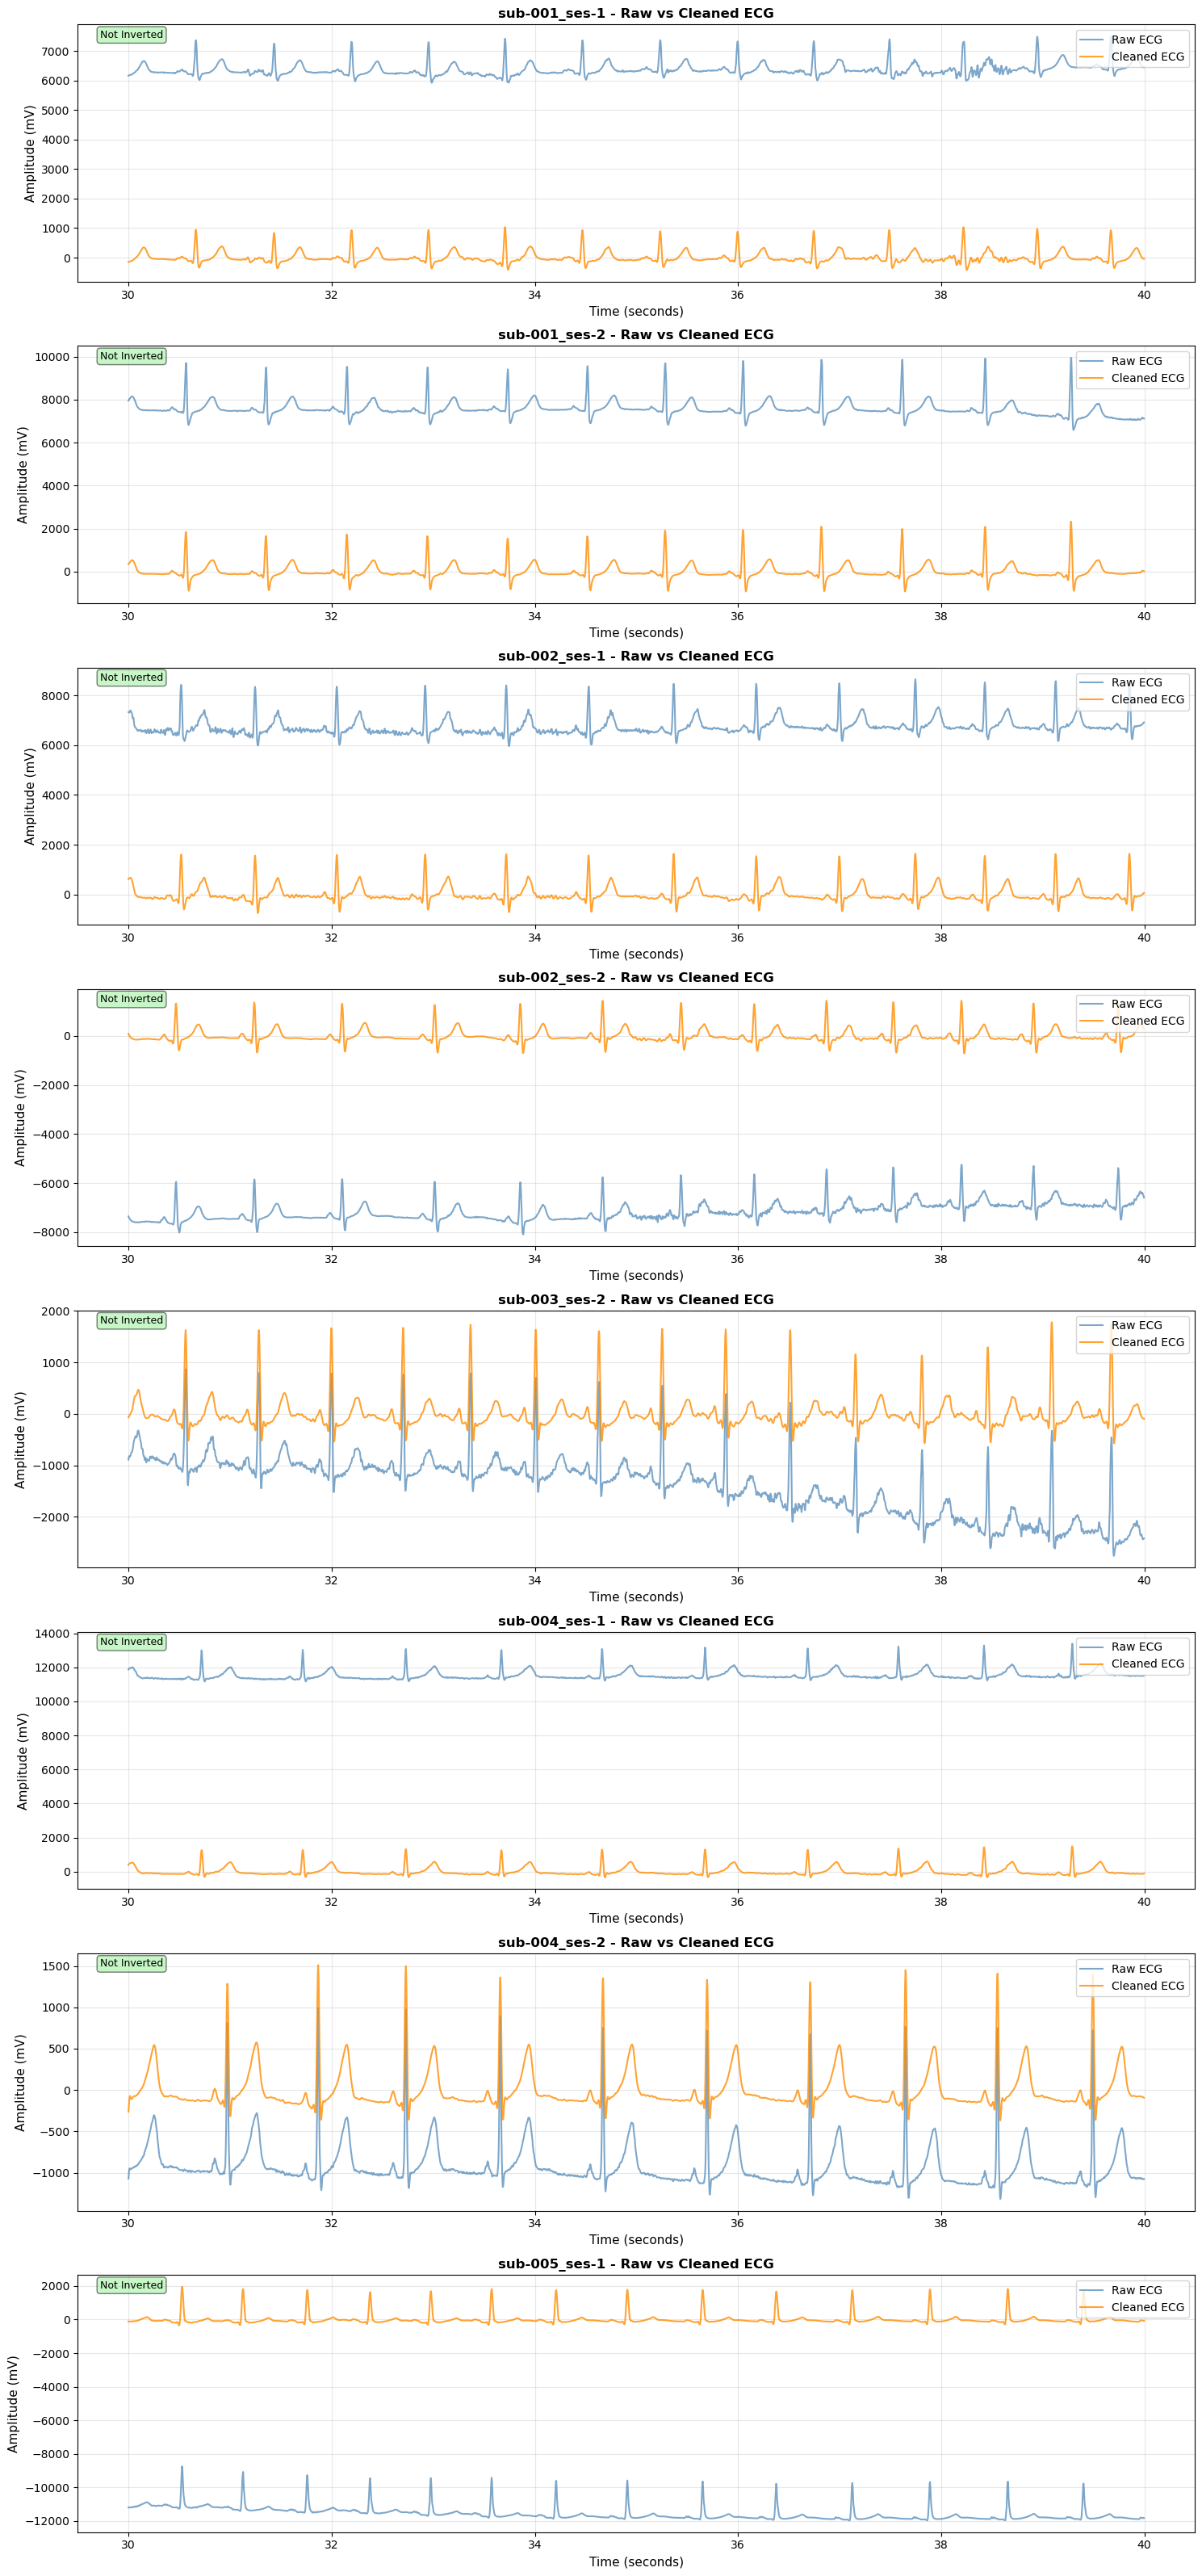


✔ Figure saved to C:\Users\alisa\OneDrive\Desktop\HRV_Biotrace\bids_data\derivatives\group_figures\ecg_preprocessing_comparison.png


In [16]:
#visualising the correction random 30 seconds
import neurokit2 as nk
import pandas as pd
import gzip
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import json

bids_root = Path(r"C:\Users\alisa\OneDrive\Desktop\HRV_Biotrace\bids_data")

# Participants with valid markers (based on your output)
valid_participants = [
    ("sub-001", "ses-1"),
    ("sub-001", "ses-2"),
    ("sub-002", "ses-1"),
    ("sub-002", "ses-2"),
    ("sub-003", "ses-2"),
    ("sub-004", "ses-1"),
    ("sub-004", "ses-2"),
    ("sub-005", "ses-1"),
]

# Create figure
n_participants = len(valid_participants)
fig, axes = plt.subplots(n_participants, 1, figsize=(15, 4 * n_participants))

# If only one participant, make axes iterable
if n_participants == 1:
    axes = [axes]

# Plot settings
duration_seconds = 10
start_time_seconds = 30

for idx, (subject, session) in enumerate(valid_participants):
    print(f"Processing {subject}_{session}...")
    
    # Paths
    beh_dir = bids_root / subject / session / "beh"
    preprocessed_dir = bids_root / subject / session / "derivatives" / "preprocessed"
    base_name = f"{subject}_{session}_task-BBSIG_physio"
    
    # Load raw ECG
    with gzip.open(beh_dir / f"{base_name}.tsv.gz", 'rt') as f:
        ecg_df = pd.read_csv(f, sep='\t', header=None, names=['cardiac'])
    ecg_raw = ecg_df['cardiac'].values
    
    # Load cleaned ECG
    ecg_clean_df = pd.read_csv(preprocessed_dir / f"{base_name}_preprocessed.tsv", sep='\t')
    ecg_clean = ecg_clean_df['cardiac_clean'].values
    
    # Load metadata
    with open(preprocessed_dir / f"{base_name}_preprocessing_info.json", 'r') as f:
        metadata = json.load(f)
    
    sfreq = metadata['sampling_rate']
    
    # Calculate sample indices
    start_sample = start_time_seconds * sfreq
    n_samples = duration_seconds * sfreq
    end_sample = start_sample + n_samples
    
    # Create time axis
    time = np.arange(start_sample, end_sample) / sfreq
    
    # Plot
    ax = axes[idx]
    ax.plot(time, ecg_raw[start_sample:end_sample], 
            color='steelblue', linewidth=1.5, label='Raw ECG', alpha=0.7)
    ax.plot(time, ecg_clean[start_sample:end_sample], 
            color='darkorange', linewidth=1.5, label='Cleaned ECG', alpha=0.8)
    
    # Formatting
    ax.set_xlabel('Time (seconds)', fontsize=11)
    ax.set_ylabel('Amplitude (mV)', fontsize=11)
    ax.set_title(f'{subject}_{session} - Raw vs Cleaned ECG', fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # Add preprocessing info
    inversion_status = "Inverted ✓" if metadata['was_inverted'] else "Not Inverted"
    ax.text(0.02, 0.98, inversion_status, transform=ax.transAxes,
            fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='yellow' if metadata['was_inverted'] else 'lightgreen', alpha=0.5))

plt.tight_layout()

# Save figure
fig_dir = bids_root / "derivatives" / "group_figures"
fig_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_dir / "ecg_preprocessing_comparison.png", dpi=300, bbox_inches='tight')

plt.show()

print(f"\n✔ Figure saved to {fig_dir / 'ecg_preprocessing_comparison.png'}")

In [18]:
#correcting the timestamps, just checking if it works
import pandas as pd
import gzip
from pathlib import Path
import json
import re

raw_marker_dir = Path(r"C:\Users\alisa\OneDrive\Desktop\HRV_Biotrace\marker_txt_raw")
bids_root = Path(r"C:\Users\alisa\OneDrive\Desktop\HRV_Biotrace\bids_data")

def parse_marker_file_correct(filepath):
    """
    Parse BioTrace marker file correctly - first column is ECG data, not time!
    Events are marked by their ROW NUMBER in the file.
    """
    print(f"\nParsing {filepath.name}")
    
    # Read file
    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        lines = f.readlines()
    
    # Extract duration and sampling rate from header
    recording_duration = None
    sampling_rate = None
    
    for line in lines[:20]:
        if 'Dauer:' in line:
            parts = line.split()
            for i, part in enumerate(parts):
                if 'Dauer:' in part:
                    try:
                        recording_duration = float(parts[i+1])
                        print(f"  → Recording duration: {recording_duration} seconds")
                    except:
                        pass
        
        if 'Abtastrate:' in line or 'SPS' in line:
            parts = line.split()
            for part in parts:
                if part.isdigit():
                    sampling_rate = int(part)
                    print(f"  → Sampling rate: {sampling_rate} Hz")
                    break
    
    if recording_duration is None or sampling_rate is None:
        raise ValueError(f"Could not extract duration or sampling rate from {filepath.name}")
    
    # Find where data starts
    data_start_idx = None
    for idx, line in enumerate(lines):
        if 'Sensor-B:EEG' in line and 'Ereignisse' in line:
            data_start_idx = idx + 1
            break
    
    if data_start_idx is None:
        raise ValueError(f"Could not find data start in {filepath.name}")
    
    # Parse data and find markers by ROW NUMBER
    start_marker_row = None
    end_marker_row = None
    
    row_number = 0  # Count from start of data
    
    for line in lines[data_start_idx:]:
        parts = line.strip().split('\t')
        
        if len(parts) >= 2:
            event = parts[1].strip().lower()
            
            # Check for start marker
            if event and any(keyword in event for keyword in ['start', 'beginn', 'begin']) and 'stimulation' in event:
                start_marker_row = row_number
                print(f"  → Found START marker at row {row_number}: '{parts[1].strip()}'")
            
            # Check for end marker
            if event and any(keyword in event for keyword in ['stop', 'ende', 'end']) and 'stimulation' in event:
                end_marker_row = row_number
                print(f"  → Found END marker at row {row_number}: '{parts[1].strip()}'")
        
        row_number += 1
    
    if start_marker_row is None or end_marker_row is None:
        raise ValueError(f"Could not find both markers in {filepath.name}")
    
    # Convert row numbers to time (in seconds)
    start_time = start_marker_row / sampling_rate
    end_time = end_marker_row / sampling_rate
    
    print(f"  → Start stimulation: {start_time:.2f}s (row {start_marker_row})")
    print(f"  → End stimulation: {end_time:.2f}s (row {end_marker_row})")
    print(f"  → Stimulation duration: {end_time - start_time:.2f}s")
    
    return start_time, end_time, recording_duration

# Test with one file first
test_file = raw_marker_dir / "sub001_01_mit.txt"
try:
    start, end, duration = parse_marker_file_correct(test_file)
    print(f"\n✓ Success!")
    print(f"  Start: {start:.2f}s")
    print(f"  End: {end:.2f}s")
    print(f"  Recording: {duration:.2f}s")
    
    # Check if times make sense
    if 0 < start < end < duration:
        print(f"  ✓ Timestamps look valid!")
    else:
        print(f"  ✗ Warning: Timestamps may still be incorrect")
        
except Exception as e:
    print(f"✗ Error: {e}")


Parsing sub001_01_mit.txt
  → Recording duration: 1794.0 seconds
  → Sampling rate: 256 Hz
  → Sampling rate: 256 Hz
  → Found START marker at row 86237: 'start stimulation'
  → Found END marker at row 387433: 'stop stimulation'
  → Start stimulation: 336.86s (row 86237)
  → End stimulation: 1513.41s (row 387433)
  → Stimulation duration: 1176.55s

✓ Success!
  Start: 336.86s
  End: 1513.41s
  Recording: 1794.00s
  ✓ Timestamps look valid!


In [7]:
#recalculating the stages for visuals

import pandas as pd
import gzip
from pathlib import Path
import json
import re

raw_marker_dir = Path(r"C:\Users\alisa\OneDrive\Desktop\HRV_Biotrace\marker_txt_raw")
bids_root = Path(r"C:\Users\alisa\OneDrive\Desktop\HRV_Biotrace\bids_data")

# Phase durations (in seconds) - YOUR DEFINITIONS
PRE_DURATION = 3 * 60  # Last 3 minutes before start
EARLY_START_OFFSET = 30  # Start 30 sec after start marker
EARLY_END_TIME = 3 * 60  # End at 3 min after start marker (so 2.5 min duration)
LATE_DURATION = 3 * 60  # 3 minutes total
LATE_END_OFFSET = 30  # End 30 sec before end marker
POST_DURATION = 3 * 60  # First 3 minutes after end

def parse_marker_file_correct(filepath):
    """
    Parse BioTrace marker file - first column is ECG data, markers by row number.
    """
    print(f"\nParsing {filepath.name}")
    
    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        lines = f.readlines()
    
    # Extract metadata
    recording_duration = None
    sampling_rate = None
    
    for line in lines[:20]:
        if 'Dauer:' in line:
            parts = line.split()
            for i, part in enumerate(parts):
                if 'Dauer:' in part:
                    try:
                        recording_duration = float(parts[i+1])
                    except:
                        pass
        
        if 'Abtastrate:' in line or 'SPS' in line:
            parts = line.split()
            for part in parts:
                if part.isdigit():
                    sampling_rate = int(part)
                    break
    
    if recording_duration is None or sampling_rate is None:
        raise ValueError(f"Could not extract duration or sampling rate")
    
    # Find data start
    data_start_idx = None
    for idx, line in enumerate(lines):
        if 'Sensor-B:EEG' in line and 'Ereignisse' in line:
            data_start_idx = idx + 1
            break
    
    if data_start_idx is None:
        raise ValueError(f"Could not find data start")
    
    # Find markers by row number
    start_marker_row = None
    end_marker_row = None
    row_number = 0
    
    for line in lines[data_start_idx:]:
        parts = line.strip().split('\t')
        
        if len(parts) >= 2:
            event = parts[1].strip().lower()
            
            if event and any(kw in event for kw in ['start', 'beginn', 'begin']) and 'stimulation' in event:
                start_marker_row = row_number
                print(f"  → START at row {row_number}: '{parts[1].strip()}'")
            
            if event and any(kw in event for kw in ['stop', 'ende', 'end']) and 'stimulation' in event:
                end_marker_row = row_number
                print(f"  → END at row {row_number}: '{parts[1].strip()}'")
        
        row_number += 1
    
    if start_marker_row is None or end_marker_row is None:
        raise ValueError(f"Could not find both markers")
    
    # Convert to time
    start_time = start_marker_row / sampling_rate
    end_time = end_marker_row / sampling_rate
    
    print(f"  → Start: {start_time:.2f}s, End: {end_time:.2f}s, Duration: {end_time - start_time:.2f}s")
    
    return start_time, end_time, recording_duration, sampling_rate

def calculate_phases(start_time, end_time, total_duration):
    """
    Calculate phase boundaries based on YOUR segment definitions.
    
    PRE:   Last 3 min before start marker
    EARLY: 30 sec to 3 min after start marker (2.5 min total)
    LATE:  3.5 min before end to 30 sec before end (3 min total)
    POST:  First 3 min after end marker
    """
    phases = {
        'pre': {
            'start': max(0, start_time - PRE_DURATION),
            'end': start_time,
            'description': 'Last 3 min before stimulation start'
        },
        'early': {
            'start': start_time + EARLY_START_OFFSET,
            'end': start_time + EARLY_END_TIME,
            'description': '30s to 3min after stimulation start'
        },
        'late': {
            'start': end_time - LATE_END_OFFSET - LATE_DURATION,
            'end': end_time - LATE_END_OFFSET,
            'description': '3.5min before end to 30s before end'
        },
        'post': {
            'start': end_time,
            'end': min(total_duration, end_time + POST_DURATION),
            'description': 'First 3 min after stimulation end'
        }
    }
    
    return phases

# Process all marker files
for marker_file in sorted(raw_marker_dir.glob("sub*_mit*.txt")):
    # Extract subject and session
    match = re.match(r"sub(\d{3})_(\d{2})_mit.*\.txt", marker_file.name)
    if not match:
        print(f"\nSkipping {marker_file.name} - doesn't match pattern")
        continue
    
    sub_id = match.group(1)
    ses_id = str(int(match.group(2)))
    
    try:
        # Parse markers
        start_time, end_time, recording_duration, sfreq = parse_marker_file_correct(marker_file)
        
        # Verify against ECG data
        preprocessed_dir = bids_root / f"sub-{sub_id}" / f"ses-{ses_id}" / "derivatives" / "preprocessed"
        base_name = f"sub-{sub_id}_ses-{ses_id}_task-BBSIG_physio"
        
        # Check if preprocessed data exists
        if not preprocessed_dir.exists():
            print(f"  ✗ No preprocessed data found for sub-{sub_id}_ses-{ses_id}")
            continue
        
        # Load ECG to verify duration
        ecg_clean_df = pd.read_csv(preprocessed_dir / f"{base_name}_preprocessed.tsv", sep='\t')
        ecg_duration = len(ecg_clean_df) / sfreq
        
        print(f"  → ECG duration: {ecg_duration:.2f}s vs Marker file: {recording_duration:.2f}s")
        
        # Calculate phases
        phases = calculate_phases(start_time, end_time, ecg_duration)
        
        # Print phase summary
        print(f"\n  Phase boundaries:")
        for phase_name, phase_data in phases.items():
            duration = phase_data['end'] - phase_data['start']
            print(f"    {phase_name.upper():6s}: {phase_data['start']:7.1f} - {phase_data['end']:7.1f}s ({duration/60:.2f} min)")
        
        # Validate phases
        all_valid = True
        for phase_name, phase_data in phases.items():
            if phase_data['start'] < 0 or phase_data['end'] > ecg_duration or phase_data['start'] >= phase_data['end']:
                print(f"    ⚠ Warning: {phase_name} phase has invalid boundaries!")
                all_valid = False
        
        if all_valid:
            print(f"  ✓ All phases valid")
        
        # Save phase information
        phases_dir = bids_root / f"sub-{sub_id}" / f"ses-{ses_id}" / "derivatives" / "phases"
        phases_dir.mkdir(parents=True, exist_ok=True)
        
        phase_info = {
            'start_marker_time': start_time,
            'end_marker_time': end_time,
            'total_duration': ecg_duration,
            'sampling_rate': sfreq,
            'phases': phases
        }
        
        with open(phases_dir / f"{base_name}_phases.json", 'w') as f:
            json.dump(phase_info, f, indent=4)
        
        print(f"  ✓ Saved phase information")
        
    except Exception as e:
        print(f"  ✗ Error: {e}")

print("\n✔ All marker files processed!")


✔ All marker files processed!


Found 7 participants with valid phase data:
  - sub-001_ses-1
  - sub-001_ses-2
  - sub-002_ses-1
  - sub-002_ses-2
  - sub-003_ses-2
  - sub-004_ses-1
  - sub-005_ses-1

Processing sub-001_ses-1...
  EARLY: 366.9 - 516.9s (2.50 min)
  LATE: 1303.4 - 1483.4s (3.00 min)

Processing sub-001_ses-2...
  EARLY: 339.7 - 489.7s (2.50 min)
  LATE: 1276.7 - 1456.7s (3.00 min)

Processing sub-002_ses-1...
  EARLY: 379.9 - 529.9s (2.50 min)
  LATE: 1318.3 - 1498.3s (3.00 min)

Processing sub-002_ses-2...
  EARLY: 357.8 - 507.8s (2.50 min)
  LATE: 1293.7 - 1473.7s (3.00 min)

Processing sub-003_ses-2...
  EARLY: 187.7 - 337.7s (2.50 min)
  LATE: 1181.4 - 1361.4s (3.00 min)

Processing sub-004_ses-1...
  EARLY: 291.6 - 441.6s (2.50 min)
  LATE: 1229.4 - 1409.4s (3.00 min)

Processing sub-005_ses-1...
  EARLY: 158.2 - 308.2s (2.50 min)
  LATE: 1097.7 - 1277.7s (3.00 min)


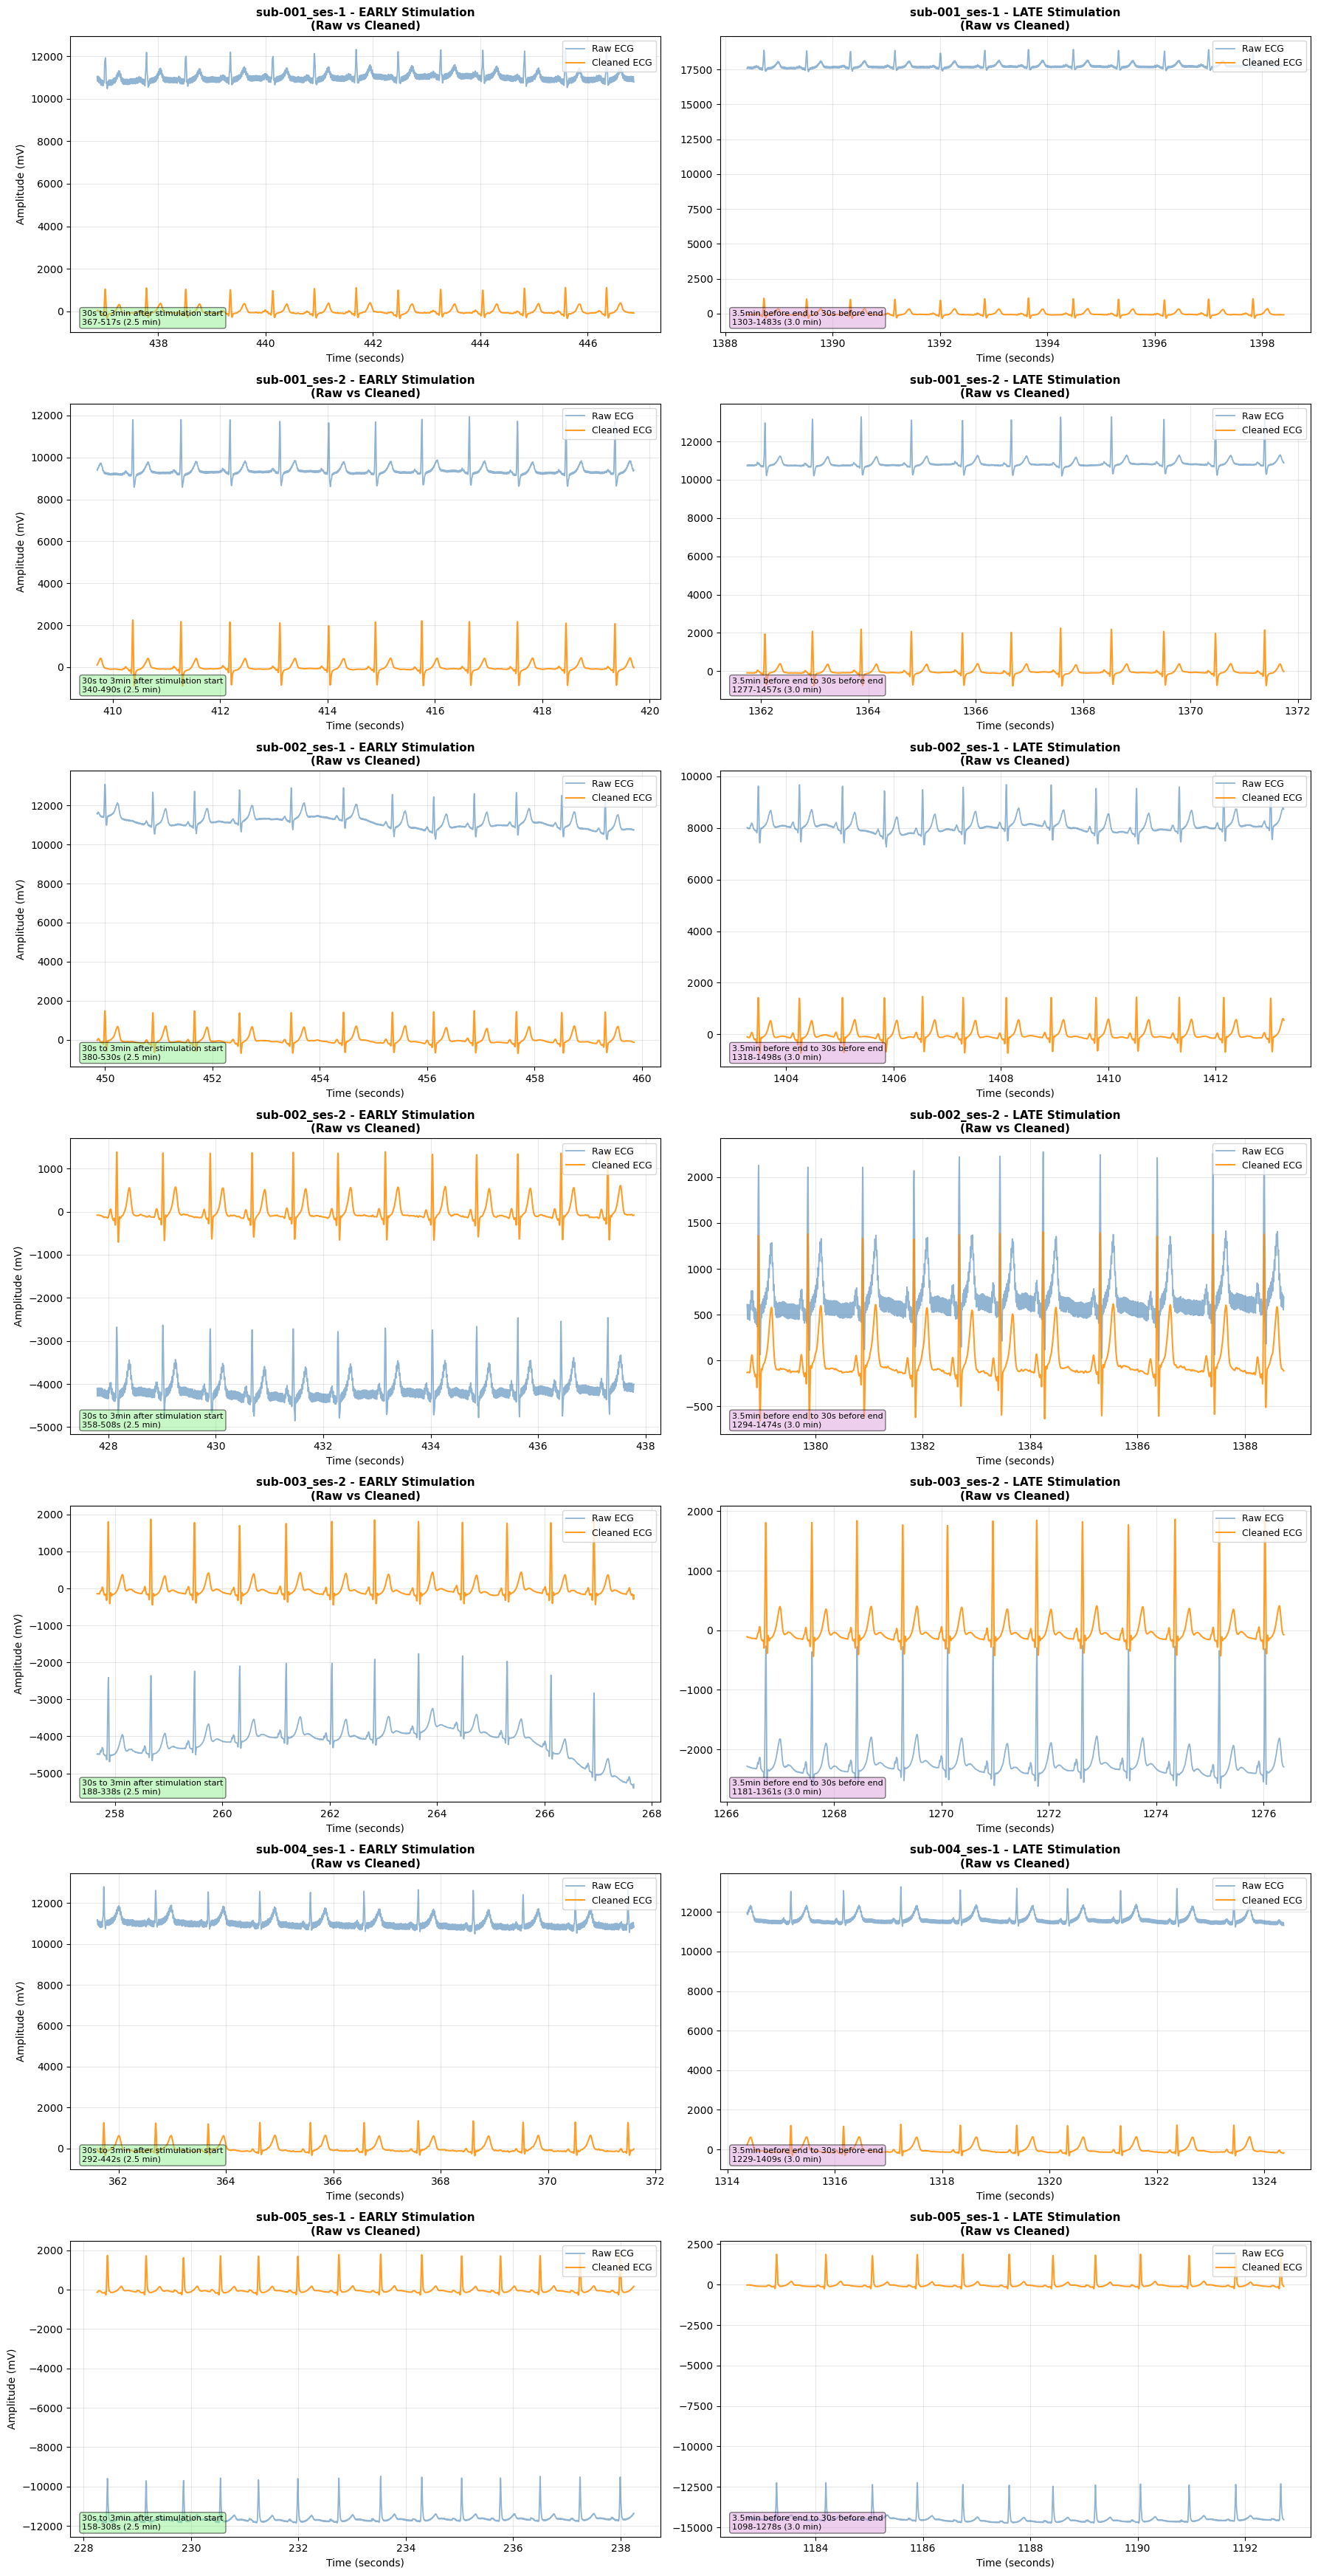


✔ Figure saved to C:\Users\alisa\OneDrive\Desktop\HRV_Biotrace\bids_data\derivatives\group_figures\ecg_raw_vs_clean_early_vs_late.png


In [23]:
#visualising the early vs late ecg filtering
import neurokit2 as nk
import pandas as pd
import gzip
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import json

bids_root = Path(r"C:\Users\alisa\OneDrive\Desktop\HRV_Biotrace\bids_data")

# Get all participants with valid phase data
valid_participants = []
for subject_dir in sorted(bids_root.iterdir()):
    if not subject_dir.name.startswith('sub-'):
        continue
    for session_dir in sorted(subject_dir.iterdir()):
        if not session_dir.name.startswith('ses-'):
            continue
        
        phases_dir = session_dir / "derivatives" / "phases"
        base_name = f"{subject_dir.name}_{session_dir.name}_task-BBSIG_physio"
        
        if (phases_dir / f"{base_name}_phases.json").exists():
            valid_participants.append((subject_dir.name, session_dir.name))

print(f"Found {len(valid_participants)} participants with valid phase data:")
for sub, ses in valid_participants:
    print(f"  - {sub}_{ses}")

# Take all the valid participants
n_participants = len(valid_participants)
participants_to_plot = valid_participants[:n_participants]

# Create figure - 2 columns (Early, Late) x N participants rows
fig, axes = plt.subplots(n_participants, 2, figsize=(18, 5 * n_participants))

# If only one participant, reshape axes
if n_participants == 1:
    axes = axes.reshape(1, -1)

# Plot settings
duration_seconds = 10  # Show 10 seconds from each phase

for idx, (subject, session) in enumerate(participants_to_plot):
    print(f"\nProcessing {subject}_{session}...")
    
    # Paths
    beh_dir = bids_root / subject / session / "beh"
    preprocessed_dir = bids_root / subject / session / "derivatives" / "preprocessed"
    phases_dir = bids_root / subject / session / "derivatives" / "phases"
    base_name = f"{subject}_{session}_task-BBSIG_physio"
    
    # Load RAW ECG
    with gzip.open(beh_dir / f"{base_name}.tsv.gz", 'rt') as f:
        ecg_df = pd.read_csv(f, sep='\t', header=None, names=['cardiac'])
    ecg_raw = ecg_df['cardiac'].values
    
    # Load CLEANED ECG
    ecg_clean_df = pd.read_csv(preprocessed_dir / f"{base_name}_preprocessed.tsv", sep='\t')
    ecg_clean = ecg_clean_df['cardiac_clean'].values
    
    # Load metadata
    with open(preprocessed_dir / f"{base_name}_preprocessing_info.json", 'r') as f:
        metadata = json.load(f)
    sfreq = metadata['sampling_rate']
    
    # Load phase information
    with open(phases_dir / f"{base_name}_phases.json", 'r') as f:
        phase_info = json.load(f)
    phases = phase_info['phases']
    
    # Plot Early and Late phases
    for col_idx, phase_name in enumerate(['early', 'late']):
        ax = axes[idx, col_idx]
        
        phase = phases[phase_name]
        phase_start = phase['start']
        phase_end = phase['end']
        phase_duration = phase_end - phase_start
        
        print(f"  {phase_name.upper()}: {phase_start:.1f} - {phase_end:.1f}s ({phase_duration/60:.2f} min)")
        
        # Get middle 10 seconds of the phase
        middle_time = (phase_start + phase_end) / 2
        plot_start_time = middle_time - (duration_seconds / 2)
        plot_end_time = middle_time + (duration_seconds / 2)
        
        # Convert to samples
        start_sample = int(plot_start_time * sfreq)
        end_sample = int(plot_end_time * sfreq)
        
        # Ensure within bounds
        start_sample = max(0, start_sample)
        end_sample = min(len(ecg_clean), end_sample)
        
        # Create time axis
        time = np.arange(start_sample, end_sample) / sfreq
        
        # Plot BOTH raw and cleaned
        ax.plot(time, ecg_raw[start_sample:end_sample], 
               color='steelblue', linewidth=1.3, label='Raw ECG', alpha=0.6)
        ax.plot(time, ecg_clean[start_sample:end_sample], 
               color='darkorange', linewidth=1.5, label='Cleaned ECG', alpha=0.85)
        
        # Formatting
        ax.set_xlabel('Time (seconds)', fontsize=10)
        if col_idx == 0:
            ax.set_ylabel('Amplitude (mV)', fontsize=10)
        
        phase_label = 'EARLY Stimulation' if phase_name == 'early' else 'LATE Stimulation'
        ax.set_title(f'{subject}_{session} - {phase_label}\n(Raw vs Cleaned)', 
                    fontsize=11, fontweight='bold')
        ax.legend(loc='upper right', fontsize=9)
        ax.grid(True, alpha=0.3)
        
        # Add phase info box
        info_text = f'{phase["description"]}\n{phase_start:.0f}-{phase_end:.0f}s ({phase_duration/60:.1f} min)'
        box_color = 'lightgreen' if phase_name == 'early' else 'plum'
        ax.text(0.02, 0.02, info_text,
               transform=ax.transAxes, fontsize=8, verticalalignment='bottom',
               bbox=dict(boxstyle='round', facecolor=box_color, alpha=0.5))

plt.tight_layout()

# Save figure
fig_dir = bids_root / "derivatives" / "group_figures"
fig_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_dir / "ecg_raw_vs_clean_early_vs_late.png", dpi=300, bbox_inches='tight')

plt.show()

print(f"\n✔ Figure saved to {fig_dir / 'ecg_raw_vs_clean_early_vs_late.png'}")

In [8]:
#step 3 r peak detection automatic
import neurokit2 as nk
import pandas as pd
from pathlib import Path
import json
import numpy as np

bids_root = Path(r"C:\Users\alisa\OneDrive\Desktop\HRV_Biotrace\bids_data")

# R-peak detection settings
rpeak_method = 'neurokit'  # Using NeuroKit2 for consistency
correct_artifacts = True

print("="*60)
print("R-PEAK DETECTION")
print(f"Method: {rpeak_method}")
print(f"Artifact correction: {correct_artifacts}")
print("="*60)

processed_count = 0
skipped_count = 0
missing_files = []

# Process all participants
for subject_dir in sorted(bids_root.iterdir()):
    if not subject_dir.name.startswith('sub-'):
        continue
    
    for session_dir in sorted(subject_dir.iterdir()):
        if not session_dir.name.startswith('ses-'):
            continue
        
        preprocessed_dir = session_dir / "derivatives" / "preprocessed"
        base_name = f"{subject_dir.name}_{session_dir.name}_task-BBSIG_physio"
        
        ecg_file = preprocessed_dir / f"{base_name}_preprocessed.tsv"
        
        # Check if preprocessed file exists
        if not ecg_file.exists():
            print(f"\n⚠ MISSING: {base_name} (no preprocessed ECG)")
            missing_files.append(base_name)
            skipped_count += 1
            continue
        
        print(f"\nProcessing {base_name}")
        
        try:
            # Load preprocessed ECG
            ecg_df = pd.read_csv(ecg_file, sep='\t')
            ecg_clean = ecg_df['cardiac_clean'].values
            
            # Load metadata
            with open(preprocessed_dir / f"{base_name}_preprocessing_info.json", 'r') as f:
                metadata = json.load(f)
            sfreq = metadata['sampling_rate']
            
            # ============================================
            # 3. R-peak detection
            # ============================================
            # Detect R-peaks using NeuroKit2
            _, rpeaks_dict = nk.ecg_peaks(
                ecg_clean, 
                sampling_rate=sfreq, 
                method=rpeak_method,
                correct_artifacts=correct_artifacts
            )
            
            # Extract R-peak indices
            rpeaks_idx = rpeaks_dict['ECG_R_Peaks']
            
            print(f"  → Detected {len(rpeaks_idx)} R-peaks")
            print(f"  → Method: {rpeak_method}")
            print(f"  → Artifact correction: {correct_artifacts}")
            
            # Calculate basic heart rate info
            if len(rpeaks_idx) > 1:
                # RR intervals in milliseconds
                rr_intervals = np.diff(rpeaks_idx) / sfreq * 1000
                mean_hr = 60000 / np.mean(rr_intervals)
                print(f"  → Mean HR: {mean_hr:.1f} bpm")
            
            # Save R-peaks
            rpeaks_dir = session_dir / "derivatives" / "rpeaks"
            rpeaks_dir.mkdir(parents=True, exist_ok=True)
            
            # Prepare data to save
            rpeaks_data = {
                'rpeaks_idx': rpeaks_idx.tolist(),
                'n_peaks': len(rpeaks_idx),
                'sampling_rate': sfreq,
                'detection_method': rpeak_method,
                'artifact_correction_applied': correct_artifacts,
                'rpeaks_uncorrected': rpeaks_dict.get('ECG_R_Peaks_Uncorrected', rpeaks_idx).tolist() if correct_artifacts else None
            }
            
            with open(rpeaks_dir / f"{base_name}_rpeaks.json", 'w') as f:
                json.dump(rpeaks_data, f, indent=4)
            
            print(f"  ✔ Completed")
            processed_count += 1
            
        except Exception as e:
            print(f"  ✗ Error: {e}")
            skipped_count += 1

print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print(f"✔ Successfully processed: {processed_count}")
print(f"⚠ Skipped/Failed: {skipped_count}")

if missing_files:
    print(f"\nMissing preprocessed files:")
    for f in missing_files:
        print(f"  - {f}")
    print(f"\nRun ECG preprocessing first for these participants.")

print("\n✔ R-peak detection complete!")

R-PEAK DETECTION
Method: neurokit
Artifact correction: True

Processing sub-001_ses-01_task-BBSIG_physio
  → Detected 2279 R-peaks
  → Method: neurokit
  → Artifact correction: True
  → Mean HR: 76.2 bpm
  ✔ Completed

Processing sub-001_ses-02_task-BBSIG_physio
  → Detected 2025 R-peaks
  → Method: neurokit
  → Artifact correction: True
  → Mean HR: 69.2 bpm
  ✔ Completed

Processing sub-002_ses-01_task-BBSIG_physio
  → Detected 2235 R-peaks
  → Method: neurokit
  → Artifact correction: True
  → Mean HR: 76.5 bpm
  ✔ Completed

Processing sub-002_ses-02_task-BBSIG_physio
  → Detected 1912 R-peaks
  → Method: neurokit
  → Artifact correction: True
  → Mean HR: 72.5 bpm
  ✔ Completed

Processing sub-003_ses-01_task-BBSIG_physio
  → Detected 1989 R-peaks
  → Method: neurokit
  → Artifact correction: True
  → Mean HR: 70.2 bpm
  ✔ Completed

Processing sub-003_ses-02_task-BBSIG_physio
  → Detected 1875 R-peaks
  → Method: neurokit
  → Artifact correction: True
  → Mean HR: 71.1 bpm
  ✔ Co

In [6]:
#phases 
import pandas as pd
from pathlib import Path
import json
import re

raw_data_dir = Path(r"C:\Users\alisa\OneDrive\Desktop\HRV_Biotrace\raw_biotrace_txt")
bids_root = Path(r"C:\Users\alisa\OneDrive\Desktop\HRV_Biotrace\bids_data")

# Phase definitions
PRE_DURATION = 3 * 60
EARLY_START_OFFSET = 30
EARLY_END_TIME = 3 * 60
LATE_DURATION = 3 * 60
LATE_END_OFFSET = 30
POST_DURATION = 3 * 60

def parse_marker_file(filepath):
    """Parse BioTrace marker file - first column is ECG data, markers by row number."""
    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        lines = f.readlines()
    
    # Extract metadata
    recording_duration = None
    sampling_rate = None
    
    for line in lines[:20]:
        if 'Dauer:' in line:
            parts = line.split()
            for i, part in enumerate(parts):
                if 'Dauer:' in part:
                    try:
                        recording_duration = float(parts[i+1])
                    except:
                        pass
        
        if 'Abtastrate:' in line or 'SPS' in line:
            parts = line.split()
            for part in parts:
                if part.isdigit():
                    sampling_rate = int(part)
                    break
    
    if recording_duration is None or sampling_rate is None:
        raise ValueError(f"Could not extract duration or sampling rate")
    
    # Find data start
    data_start_idx = None
    for idx, line in enumerate(lines):
        if 'Sensor-B:EEG' in line and 'Ereignisse' in line:
            data_start_idx = idx + 1
            break
    
    if data_start_idx is None:
        raise ValueError(f"Could not find data start")
    
    # Find markers by row number - UPDATED WITH FLEXIBLE MATCHING
    start_marker_row = None
    end_marker_row = None
    row_number = 0
    
    for line in lines[data_start_idx:]:
        parts = line.strip().split('\t')
        
        if len(parts) >= 2:
            event = parts[1].strip().lower()  # Convert to lowercase for matching
            
            if event:
                # START marker - flexible matching (no 'stimulation' required)
                if any(word in event for word in ['start', 'beginn', 'begin', 'anfang']):
                    # Take first occurrence
                    if start_marker_row is None:
                        start_marker_row = row_number
                        print(f"  → Found START marker at row {row_number}: '{parts[1].strip()}'")
                
                # END marker - flexible matching (no 'stimulation' required)
                if any(word in event for word in ['stop', 'ende', 'end', 'schluss', 'finish']):
                    # Take last occurrence (in case there are multiple)
                    end_marker_row = row_number
                    print(f"  → Found END marker at row {row_number}: '{parts[1].strip()}'")
        
        row_number += 1
    
    if start_marker_row is None or end_marker_row is None:
        raise ValueError(f"Could not find both markers")
    
    # Convert to time
    start_time = start_marker_row / sampling_rate
    end_time = end_marker_row / sampling_rate
    
    return start_time, end_time, recording_duration, sampling_rate

def calculate_phases(start_time, end_time, total_duration):
    """Calculate phase boundaries based on segment definitions"""
    phases = {
        'pre': {
            'start': max(0, start_time - PRE_DURATION),
            'end': start_time,
            'description': 'Last 3 min before stimulation start'
        },
        'early': {
            'start': start_time + EARLY_START_OFFSET,
            'end': start_time + EARLY_END_TIME,
            'description': '30s to 3min after stimulation start'
        },
        'late': {
            'start': end_time - LATE_END_OFFSET - LATE_DURATION,
            'end': end_time - LATE_END_OFFSET,
            'description': '3.5min before end to 30s before end'
        },
        'post': {
            'start': end_time,
            'end': min(total_duration, end_time + POST_DURATION),
            'description': 'First 3 min after stimulation end'
        }
    }
    
    return phases

print("="*60)
print("PARSING MARKERS AND CREATING PHASE BOUNDARIES")
print("="*60)

processed_count = 0
error_count = 0
missing_marker_files = []

# Process all marker files
for marker_file in sorted(raw_data_dir.glob("*_mit.txt")):
    # Match: sub###_##_X_mit.txt
    match = re.match(r"sub(\d{3})_(\d{2})_([ec])_mit\.txt", marker_file.name)
    if not match:
        print(f"\n⚠ Skipping {marker_file.name} - doesn't match pattern")
        continue
    
    sub_id = match.group(1)
    ses_id = match.group(2)
    condition = match.group(3)
    
    print(f"\nProcessing sub-{sub_id}_ses-{ses_id} ({condition})...")
    
    try:
        # Parse markers
        start_time, end_time, recording_duration, sfreq = parse_marker_file(marker_file)
        
        print(f"  → Start: {start_time:.2f}s, End: {end_time:.2f}s")
        
        # Get ECG duration from preprocessed data
        preprocessed_dir = bids_root / f"sub-{sub_id}" / f"ses-{ses_id}" / "derivatives" / "preprocessed"
        base_name = f"sub-{sub_id}_ses-{ses_id}_task-BBSIG_physio"
        
        if not preprocessed_dir.exists():
            print(f"  ✗ No preprocessed data found - run ECG preprocessing first")
            error_count += 1
            continue
        
        ecg_clean_file = preprocessed_dir / f"{base_name}_preprocessed.tsv"
        if not ecg_clean_file.exists():
            print(f"  ✗ No preprocessed ECG file found")
            error_count += 1
            continue
        
        ecg_clean_df = pd.read_csv(ecg_clean_file, sep='\t')
        ecg_duration = len(ecg_clean_df) / sfreq
        
        print(f"  → ECG duration: {ecg_duration:.2f}s")
        
        # Calculate phases
        phases = calculate_phases(start_time, end_time, ecg_duration)
        
        # Print phase boundaries
        print(f"  → Phase boundaries:")
        for phase_name, phase_data in phases.items():
            duration = phase_data['end'] - phase_data['start']
            print(f"     {phase_name.upper():6s}: {phase_data['start']:7.1f} - {phase_data['end']:7.1f}s ({duration/60:.2f} min)")
        
        # Validate phases
        all_valid = all(
            0 <= p['start'] < p['end'] <= ecg_duration
            for p in phases.values()
        )
        
        if all_valid:
            print(f"  ✓ All phases valid")
        else:
            print(f"  ⚠ Some phases invalid - check boundaries")
        
        # Save phase info
        phases_dir = bids_root / f"sub-{sub_id}" / f"ses-{ses_id}" / "derivatives" / "phases"
        phases_dir.mkdir(parents=True, exist_ok=True)
        
        phase_info = {
            'start_marker_time': start_time,
            'end_marker_time': end_time,
            'total_duration': ecg_duration,
            'sampling_rate': sfreq,
            'condition': 'experimental' if condition == 'e' else 'control',
            'phases': phases
        }
        
        with open(phases_dir / f"{base_name}_phases.json", 'w') as f:
            json.dump(phase_info, f, indent=4)
        
        print(f"  ✓ Saved phase information")
        processed_count += 1
        
    except Exception as e:
        print(f"  ✗ Error: {e}")
        error_count += 1

print("\n" + "="*60)
print("MARKER PROCESSING COMPLETE")
print("="*60)
print(f"✔ Successfully processed: {processed_count}")
print(f"✗ Errors/Skipped: {error_count}")

if error_count > 0:
    print(f"\n⚠ {error_count} files had errors")
    print("  Common reasons:")
    print("  - Marker file missing or incorrectly named")
    print("  - Preprocessed ECG data not available (run ECG preprocessing first)")
    print("  - Marker timestamps incorrect")

print("\n" + "="*60)

PARSING MARKERS AND CREATING PHASE BOUNDARIES

Processing sub-001_ses-01 (c)...
  → Found START marker at row 86237: 'start stimulation'
  → Found END marker at row 387433: 'stop stimulation'
  → Start: 336.86s, End: 1513.41s
  → ECG duration: 1794.00s
  → Phase boundaries:
     PRE   :   156.9 -   336.9s (3.00 min)
     EARLY :   366.9 -   516.9s (2.50 min)
     LATE  :  1303.4 -  1483.4s (3.00 min)
     POST  :  1513.4 -  1693.4s (3.00 min)
  ✓ All phases valid
  ✓ Saved phase information

Processing sub-001_ses-02 (e)...
  → Found START marker at row 79286: 'start stimulation'
  → Found END marker at row 380606: 'stop stimulation'
  → Start: 309.71s, End: 1486.74s
  → ECG duration: 1757.00s
  → Phase boundaries:
     PRE   :   129.7 -   309.7s (3.00 min)
     EARLY :   339.7 -   489.7s (2.50 min)
     LATE  :  1276.7 -  1456.7s (3.00 min)
     POST  :  1486.7 -  1666.7s (3.00 min)
  ✓ All phases valid
  ✓ Saved phase information

Processing sub-002_ses-01 (e)...
  → Found START mark

In [4]:
#visual quality checks - old bids structure
import neurokit2 as nk
import pandas as pd
from pathlib import Path
import json
import matplotlib.pyplot as plt
import numpy as np

bids_root = Path(r"C:\Users\alisa\OneDrive\Desktop\HRV_Biotrace\bids_data")

# Create QC output directory
qc_dir = bids_root / "derivatives" / "quality_control"
qc_dir.mkdir(parents=True, exist_ok=True)

print("="*60)
print("GENERATING R-PEAK QUALITY CONTROL REPORTS")
print("Showing 10-second snippets from each experimental phase")
print("="*60)

quality_issues = []
processed_count = 0
skipped_count = 0

for subject_dir in sorted(bids_root.iterdir()):
    if not subject_dir.name.startswith('sub-'):
        continue
    
    for session_dir in sorted(subject_dir.iterdir()):
        if not session_dir.name.startswith('ses-'):
            continue
        
        preprocessed_dir = session_dir / "derivatives" / "preprocessed"
        rpeaks_dir = session_dir / "derivatives" / "rpeaks"
        phases_dir = session_dir / "derivatives" / "phases"
        base_name = f"{subject_dir.name}_{session_dir.name}_task-BBSIG_physio"
        
        # Check if files exist
        ecg_file = preprocessed_dir / f"{base_name}_preprocessed.tsv"
        rpeaks_file = rpeaks_dir / f"{base_name}_rpeaks.json"
        phases_file = phases_dir / f"{base_name}_phases.json"
        
        if not ecg_file.exists():
            print(f"\n⚠ Skipping {base_name} - no preprocessed ECG")
            skipped_count += 1
            continue
            
        if not rpeaks_file.exists():
            print(f"\n⚠ Skipping {base_name} - no R-peaks detected")
            skipped_count += 1
            continue
        
        if not phases_file.exists():
            print(f"\n⚠ Skipping {base_name} - no phase information")
            skipped_count += 1
            continue
        
        print(f"\nProcessing {base_name}")
        
        try:
            # ==========================================
            # LOAD DATA
            # ==========================================
            
            # Load ECG signal
            ecg_df = pd.read_csv(ecg_file, sep='\t')
            ecg_clean = ecg_df['cardiac_clean'].values
            
            # Load R-peaks
            with open(rpeaks_file, 'r') as f:
                rpeaks_data = json.load(f)
            rpeaks_idx = np.array(rpeaks_data['rpeaks_idx'])
            
            # Load metadata
            with open(preprocessed_dir / f"{base_name}_preprocessing_info.json", 'r') as f:
                metadata = json.load(f)
            sfreq = metadata['sampling_rate']
            
            # Load phases
            with open(phases_file, 'r') as f:
                phase_data = json.load(f)
            phases = phase_data['phases']
            condition = phase_data.get('condition', 'unknown')
            
            print(f"  → Condition: {condition}")
            print(f"  → {len(rpeaks_idx)} R-peaks detected")
            print(f"  → Duration: {len(ecg_clean)/sfreq/60:.1f} minutes")
            
            # ==========================================
            # IDENTIFY PHASE BOUNDARIES
            # ==========================================
            
            print(f"\n  Phase boundaries:")
            for phase_name in ['pre', 'early', 'late', 'post']:
                phase = phases[phase_name]
                start_time = phase['start']
                end_time = phase['end']
                duration = (end_time - start_time) / 60
                print(f"    {phase_name.upper():6s}: {start_time:7.1f} - {end_time:7.1f} s ({duration:.2f} min)")
            
            # ==========================================
            # CALCULATE QUALITY METRICS (ENTIRE RECORDING)
            # ==========================================
            
            # RR intervals and heart rate
            rr_intervals = np.diff(rpeaks_idx) / sfreq * 1000  # in ms
            heart_rate = 60000 / rr_intervals  # in bpm
            
            # Overall statistics
            mean_hr = np.mean(heart_rate)
            std_hr = np.std(heart_rate)
            min_hr = np.min(heart_rate)
            max_hr = np.max(heart_rate)
            
            mean_rr = np.mean(rr_intervals)
            std_rr = np.std(rr_intervals)
            min_rr = np.min(rr_intervals)
            max_rr = np.max(rr_intervals)
            
            # Artifact detection
            very_short = np.sum(rr_intervals < 300)  # < 300ms (physiologically unlikely)
            very_long = np.sum(rr_intervals > 2000)  # > 2000ms (missed beat or artifact)
            total_beats = len(rr_intervals)
            
            # Flag potential issues
            has_issues = False
            issues = []
            
            if mean_hr < 40 or mean_hr > 120:
                has_issues = True
                issues.append(f"Unusual mean HR: {mean_hr:.1f} bpm (expected 40-120)")
            
            if std_hr > 30:
                has_issues = True
                issues.append(f"High HR variability: {std_hr:.1f} bpm (>30)")
            
            if min_hr < 30 or max_hr > 180:
                has_issues = True
                issues.append(f"Extreme HR values: {min_hr:.1f}-{max_hr:.1f} bpm")
            
            if very_short > total_beats * 0.01:  # >1% of beats
                has_issues = True
                issues.append(f"{very_short} very short RR intervals (<300ms, {very_short/total_beats*100:.2f}%)")
            
            if very_long > total_beats * 0.01:
                has_issues = True
                issues.append(f"{very_long} very long RR intervals (>2000ms, {very_long/total_beats*100:.2f}%)")
            
            print(f"\n  Quality metrics:")
            print(f"    Mean HR: {mean_hr:.1f} ± {std_hr:.1f} bpm")
            print(f"    Artifacts: {very_short + very_long} ({(very_short + very_long)/total_beats*100:.2f}%)")
            print(f"    Status: {'⚠ NEEDS REVIEW' if has_issues else '✓ GOOD'}")
            
            # ==========================================
            # CREATE VISUALIZATION
            # ==========================================
            
            fig = plt.figure(figsize=(20, 14))
            
            # ==========================================
            # ROW 1: 10-second ECG snippets from each phase
            # ==========================================
            
            phase_colors = {
                'pre': 'steelblue',
                'early': 'green',
                'late': 'purple',
                'post': 'orange'
            }
            
            for idx, phase_name in enumerate(['pre', 'early', 'late', 'post']):
                ax = plt.subplot(4, 4, idx + 1)
                
                phase = phases[phase_name]
                phase_start = phase['start']
                phase_end = phase['end']
                
                # Get middle 10 seconds of the phase
                middle_time = (phase_start + phase_end) / 2
                snippet_start_time = middle_time - 5  # 5 seconds before middle
                snippet_end_time = middle_time + 5    # 5 seconds after middle
                
                # Convert to samples
                start_sample = int(snippet_start_time * sfreq)
                end_sample = int(snippet_end_time * sfreq)
                
                # Ensure within bounds
                start_sample = max(0, start_sample)
                end_sample = min(len(ecg_clean), end_sample)
                
                # Time array for plotting
                time = np.arange(start_sample, end_sample) / sfreq
                
                # Plot ECG
                ax.plot(time, ecg_clean[start_sample:end_sample], 
                       color=phase_colors[phase_name], linewidth=1, alpha=0.7)
                
                # Plot R-peaks in this window
                rpeaks_in_window = rpeaks_idx[(rpeaks_idx >= start_sample) & (rpeaks_idx < end_sample)]
                if len(rpeaks_in_window) > 0:
                    ax.plot(rpeaks_in_window / sfreq, ecg_clean[rpeaks_in_window], 
                           'ro', markersize=6, label=f'{len(rpeaks_in_window)} R-peaks')
                
                ax.set_xlabel('Time (s)', fontsize=10)
                ax.set_ylabel('Amplitude (mV)', fontsize=10)
                ax.set_title(f'{phase_name.upper()} Phase (10s snippet)', 
                            fontsize=11, fontweight='bold', color=phase_colors[phase_name])
                ax.grid(True, alpha=0.3)
                ax.legend(fontsize=9)
            
            # ==========================================
            # ROW 2: Heart Rate and RR Intervals Over Time
            # ==========================================
            
            # Heart Rate over entire recording
            ax5 = plt.subplot(4, 4, (5, 6))
            time_hr = (rpeaks_idx[1:] / sfreq) / 60  # in minutes
            ax5.plot(time_hr, heart_rate, 'k-', linewidth=1, alpha=0.7)
            ax5.axhline(y=mean_hr, color='r', linestyle='--', linewidth=2, label=f'Mean: {mean_hr:.1f} bpm')
            ax5.axhline(y=mean_hr + std_hr, color='orange', linestyle=':', alpha=0.7, label='±1 SD')
            ax5.axhline(y=mean_hr - std_hr, color='orange', linestyle=':', alpha=0.7)
            
            # Mark phase boundaries
            for phase_name in ['pre', 'early', 'late', 'post']:
                phase = phases[phase_name]
                ax5.axvspan(phase['start']/60, phase['end']/60, 
                           color=phase_colors[phase_name], alpha=0.1)
            
            ax5.set_xlabel('Time (minutes)', fontsize=11)
            ax5.set_ylabel('Heart Rate (bpm)', fontsize=11)
            ax5.set_title('Heart Rate Over Time (with phase boundaries)', fontsize=12, fontweight='bold')
            ax5.legend(fontsize=10)
            ax5.grid(True, alpha=0.3)
            
            # RR Intervals over time
            ax6 = plt.subplot(4, 4, (7, 8))
            ax6.plot(rr_intervals, 'b-', linewidth=0.5, alpha=0.7)
            ax6.axhline(y=mean_rr, color='r', linestyle='--', linewidth=2, label=f'Mean: {mean_rr:.0f} ms')
            ax6.axhline(y=300, color='orange', linestyle=':', linewidth=1.5, label='300ms threshold')
            ax6.axhline(y=2000, color='orange', linestyle=':', linewidth=1.5, label='2000ms threshold')
            
            ax6.set_xlabel('Beat Number', fontsize=11)
            ax6.set_ylabel('RR Interval (ms)', fontsize=11)
            ax6.set_title('RR Intervals (Entire Recording)', fontsize=12, fontweight='bold')
            ax6.legend(fontsize=10)
            ax6.grid(True, alpha=0.3)
            ax6.set_ylim([max(0, mean_rr - 3*std_rr), mean_rr + 3*std_rr])
            
            # ==========================================
            # ROW 3: Distributions
            # ==========================================
            
            # RR interval histogram
            ax9 = plt.subplot(4, 4, 9)
            ax9.hist(rr_intervals, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
            ax9.axvline(x=mean_rr, color='r', linestyle='--', linewidth=2, label=f'Mean: {mean_rr:.0f} ms')
            ax9.axvline(x=300, color='orange', linestyle=':', linewidth=1.5, alpha=0.7)
            ax9.axvline(x=2000, color='orange', linestyle=':', linewidth=1.5, alpha=0.7)
            ax9.set_xlabel('RR Interval (ms)', fontsize=10)
            ax9.set_ylabel('Count', fontsize=10)
            ax9.set_title('RR Interval Distribution', fontsize=11, fontweight='bold')
            ax9.legend(fontsize=9)
            ax9.grid(True, alpha=0.3)
            
            # Heart Rate histogram
            ax10 = plt.subplot(4, 4, 10)
            ax10.hist(heart_rate, bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
            ax10.axvline(x=mean_hr, color='r', linestyle='--', linewidth=2, label=f'Mean: {mean_hr:.1f} bpm')
            ax10.set_xlabel('Heart Rate (bpm)', fontsize=10)
            ax10.set_ylabel('Count', fontsize=10)
            ax10.set_title('Heart Rate Distribution', fontsize=11, fontweight='bold')
            ax10.legend(fontsize=9)
            ax10.grid(True, alpha=0.3)
            
            # Poincaré plot
            ax11 = plt.subplot(4, 4, 11)
            ax11.scatter(rr_intervals[:-1], rr_intervals[1:], alpha=0.3, s=8, c='blue')
            ax11.plot([min_rr, max_rr], [min_rr, max_rr], 'r--', alpha=0.5, linewidth=2)
            ax11.set_xlabel('RR(n) (ms)', fontsize=10)
            ax11.set_ylabel('RR(n+1) (ms)', fontsize=10)
            ax11.set_title('Poincaré Plot', fontsize=11, fontweight='bold')
            ax11.grid(True, alpha=0.3)
            
            # Set reasonable limits (exclude extreme outliers for better visualization)
            p1, p99 = np.percentile(rr_intervals, [1, 99])
            ax11.set_xlim([p1, p99])
            ax11.set_ylim([p1, p99])
            
            # ==========================================
            # ROW 4: Quality Summary (spans multiple cells)
            # ==========================================
            
            ax13 = plt.subplot(4, 4, (13, 16))
            ax13.axis('off')
            
            summary_text = f"""
╔═══════════════════════════════════════════════════════════════════════════════════╗
║  QUALITY CONTROL SUMMARY - {base_name}
╚═══════════════════════════════════════════════════════════════════════════════════╝

RECORDING INFORMATION
─────────────────────────────────────────────────────────────────────────────────────
  Total R-peaks detected:     {len(rpeaks_idx)}
  Recording duration:         {len(ecg_clean)/sfreq/60:.2f} minutes
  Sampling rate:              {sfreq} Hz
  Condition:                  {condition.upper()}

HEART RATE STATISTICS (ENTIRE RECORDING)
─────────────────────────────────────────────────────────────────────────────────────
  Mean ± SD:                  {mean_hr:.1f} ± {std_hr:.1f} bpm
  Range:                      {min_hr:.1f} - {max_hr:.1f} bpm
  Expected range:             40 - 120 bpm

RR INTERVAL STATISTICS (ENTIRE RECORDING)
─────────────────────────────────────────────────────────────────────────────────────
  Mean ± SD:                  {mean_rr:.1f} ± {std_rr:.1f} ms
  Range:                      {min_rr:.1f} - {max_rr:.1f} ms

ARTIFACT DETECTION
─────────────────────────────────────────────────────────────────────────────────────
  Very short intervals (<300ms):    {very_short} ({very_short/total_beats*100:.2f}%)
  Very long intervals (>2000ms):    {very_long} ({very_long/total_beats*100:.2f}%)
  Total artifacts:                  {very_short + very_long} ({(very_short + very_long)/total_beats*100:.2f}%)
  
  Threshold for concern:            >1% artifacts

EXPERIMENTAL PHASES
─────────────────────────────────────────────────────────────────────────────────────
  PRE:     {phases['pre']['start']:6.1f} - {phases['pre']['end']:7.1f} s  ({(phases['pre']['end']-phases['pre']['start'])/60:.2f} min)
  EARLY:   {phases['early']['start']:6.1f} - {phases['early']['end']:7.1f} s  ({(phases['early']['end']-phases['early']['start'])/60:.2f} min)
  LATE:    {phases['late']['start']:6.1f} - {phases['late']['end']:7.1f} s  ({(phases['late']['end']-phases['late']['start'])/60:.2f} min)
  POST:    {phases['post']['start']:6.1f} - {phases['post']['end']:7.1f} s  ({(phases['post']['end']-phases['post']['start'])/60:.2f} min)

═════════════════════════════════════════════════════════════════════════════════════
OVERALL QUALITY ASSESSMENT: {'⚠ NEEDS MANUAL REVIEW' if has_issues else '✓ GOOD - NO ACTION NEEDED'}
═════════════════════════════════════════════════════════════════════════════════════
            """
            
            if has_issues:
                summary_text += "\n\nISSUES FLAGGED FOR REVIEW:\n"
                summary_text += "─────────────────────────────────────────────────────────────────────────────────────\n"
                for issue in issues:
                    summary_text += f"  ⚠ {issue}\n"
                summary_text += "\n→ RECOMMENDATION: Visually inspect R-peaks in flagged segments\n"
                summary_text += "→ If R-peaks look obviously wrong, manual correction may be needed\n"
            else:
                summary_text += "\n\n✓ All quality metrics within acceptable ranges\n"
                summary_text += "✓ R-peak detection appears successful\n"
                summary_text += "✓ Ready for HRV analysis\n"
            
            # Choose background color based on quality
            bg_color = 'lightyellow' if has_issues else 'lightgreen'
            edge_color = 'red' if has_issues else 'darkgreen'
            
            ax13.text(0.02, 0.98, summary_text, transform=ax13.transAxes,
                    fontsize=9, verticalalignment='top', fontfamily='monospace',
                    bbox=dict(boxstyle='round', facecolor=bg_color, 
                             alpha=0.9, edgecolor=edge_color, linewidth=3))
            
            # Overall title
            title_color = 'red' if has_issues else 'green'
            plt.suptitle(f'R-PEAK QUALITY CONTROL REPORT - {base_name}', 
                        fontsize=16, fontweight='bold', color=title_color)
            plt.tight_layout(rect=[0, 0, 1, 0.98])
            
            # ==========================================
            # SAVE FIGURE
            # ==========================================
            
            fig_path = qc_dir / f"{base_name}_rpeak_qc.png"
            plt.savefig(fig_path, dpi=150, bbox_inches='tight')
            plt.close()
            
            print(f"  ✓ QC report saved")
            
            # Track quality issues
            if has_issues:
                quality_issues.append({
                    'participant': base_name,
                    'condition': condition,
                    'issues': issues
                })
            
            processed_count += 1
            
        except Exception as e:
            print(f"  ✗ Error: {e}")
            import traceback
            traceback.print_exc()
            skipped_count += 1

# ==========================================
# FINAL SUMMARY
# ==========================================

print("\n" + "="*80)
print("QC GENERATION COMPLETE")
print("="*80)

print(f"\nProcessed:        {processed_count} recordings")
print(f"Skipped:          {skipped_count} recordings")
print(f"Quality issues:   {len(quality_issues)} recordings flagged")

if quality_issues:
    print("\n" + "="*80)
    print("RECORDINGS FLAGGED FOR MANUAL REVIEW")
    print("="*80)
    
    for item in quality_issues:
        print(f"\n  📋 {item['participant']} ({item['condition']})")
        for issue in item['issues']:
            print(f"     ⚠ {issue}")
    
    print("\n" + "="*80)
    print("NEXT STEPS FOR FLAGGED RECORDINGS:")
    print("="*80)
    print("1. Open the QC report images for flagged recordings")
    print("2. Visually inspect the 10-second ECG snippets from each phase")
    print("3. Check if R-peaks (red dots) are correctly placed on ECG peaks")
    print("4. If R-peaks look correct despite flags → proceed to HRV analysis")
    print("5. If R-peaks are clearly wrong → manual correction needed (we'll help)")
else:
    print("\n✓ All recordings passed automated quality checks!")
    print("✓ No manual review needed - proceed to HRV analysis!")

print(f"\n📁 All QC reports saved to:")
print(f"   {qc_dir}")

print("\n" + "="*80)

GENERATING R-PEAK QUALITY CONTROL REPORTS
Showing 10-second snippets from each experimental phase

Processing sub-001_ses-01_task-BBSIG_physio
  → Condition: control
  → 2279 R-peaks detected
  → Duration: 29.9 minutes

  Phase boundaries:
    PRE   :   156.9 -   336.9 s (3.00 min)
    EARLY :   366.9 -   516.9 s (2.50 min)
    LATE  :  1303.4 -  1483.4 s (3.00 min)
    POST  :  1513.4 -  1693.4 s (3.00 min)

  Quality metrics:
    Mean HR: 76.6 ± 5.1 bpm
    Artifacts: 0 (0.00%)
    Status: ✓ GOOD
  ✓ QC report saved

Processing sub-001_ses-02_task-BBSIG_physio
  → Condition: experimental
  → 2025 R-peaks detected
  → Duration: 29.3 minutes

  Phase boundaries:
    PRE   :   129.7 -   309.7 s (3.00 min)
    EARLY :   339.7 -   489.7 s (2.50 min)
    LATE  :  1276.7 -  1456.7 s (3.00 min)
    POST  :  1486.7 -  1666.7 s (3.00 min)

  Quality metrics:
    Mean HR: 69.6 ± 5.2 bpm
    Artifacts: 0 (0.00%)
    Status: ✓ GOOD
  ✓ QC report saved

Processing sub-002_ses-01_task-BBSIG_physio


In [15]:
#skipping detailed manual changes, systole not working
from systole.viewer import Viewer
from pathlib import Path

bids_root = Path(r"C:\Users\alisa\OneDrive\Desktop\HRV_Biotrace\bids_data")

# Launch Systole Viewer for your BIDS dataset
print("="*60)
print("LAUNCHING SYSTOLE VIEWER")
print("="*60)
print("This will open an interactive viewer for all your BIDS data")
print("="*60)

viewer = Viewer(
    input_folder=str(bids_root),
    pattern="task-BBSIG",
    modality="beh",
    signal_type="ECG"
)
## For Your Thesis Documentation:

#Include in your methods section:

#"R-peak detection was performed using NeuroKit2's automated algorithm 
#(ecg_peaks, method='neurokit') with artifact correction enabled. Quality 
#control was conducted on all recordings (n=40) by visual inspection of:
#(1) ECG signal with detected R-peaks, (2) heart rate time series, 
#(3) RR interval distribution, and (4) Poincaré plots. Recordings with 
#mean heart rate outside 40-120 bpm, standard deviation >30 bpm, or 
#>5% of RR intervals <300ms or >2000ms were flagged for manual review. 
#[X recordings required manual correction / All recordings passed 
#automated quality control]."

ModuleNotFoundError: No module named 'systole.viewer'

In [16]:
# what's available in the updated systole
import systole
print(f"Systole version: {systole.__version__}")
print("\nAvailable modules:")
print(dir(systole))

# Check if there's a recording module
try:
    from systole import recording
    print("\nRecording module found!")
    print(dir(recording))
except:
    print("\nNo recording module")

# Check for plots
try:
    from systole import plots
    print("\nPlots module:")
    print([x for x in dir(plots) if not x.startswith('_')])
except:
    print("\nNo plots module")

Systole version: 0.3.0

Available modules:
['Dict', 'List', 'Optional', 'Path', 'Tuple', 'Union', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'all_domain', 'cdist', 'christov', 'correct_ectopic_peaks', 'correct_extra_rr', 'correct_missed_peaks', 'correct_missed_rr', 'correct_peaks', 'correct_rr', 'correction', 'datasets', 'detect_heartbeats', 'detection', 'detectors', 'ecg_peaks', 'ecg_strings', 'engelse_zeelenberg', 'find_clipping', 'frequency_domain', 'get_valid_segments', 'hamilton', 'heart_rate', 'hrv', 'import_dataset1', 'import_manual_correction', 'import_ppg', 'import_rr', 'input_conversion', 'interp1d', 'interpolate', 'interpolate_clipping', 'interpolate_rr', 'io', 'jit', 'json', 'moving_average', 'msptd', 'nan_cleaning', 'nnX', 'nonlinear_domain', 'norm', 'norm_bad_segments', 'norm_triggers', 'np', 'pan_tompkins', 'pd', 'plot_circular', 'plot_ectopic', 'plot_events', 'plot_evoked', 'plot_f

In [20]:
import systole
import pandas as pd
import numpy as np
from pathlib import Path
import json

bids_root = Path(r"C:\Users\alisa\OneDrive\Desktop\HRV_Biotrace\bids_data")

subject = "sub-005"
session = "ses-01"

preprocessed_dir = bids_root / subject / session / "derivatives" / "preprocessed"
rpeaks_dir = bids_root / subject / session / "derivatives" / "rpeaks"
base_name = f"{subject}_{session}_task-BBSIG_physio"

print(f"Loading data for {base_name}...")

# Load ECG
ecg_df = pd.read_csv(preprocessed_dir / f"{base_name}_preprocessed.tsv", sep='\t')
ecg_clean = ecg_df['cardiac_clean'].values

# Load existing R-peaks
with open(rpeaks_dir / f"{base_name}_rpeaks.json", 'r') as f:
    rpeaks_data = json.load(f)
rpeaks_idx = np.array(rpeaks_data['rpeaks_idx'])

sfreq = 256

# Convert to boolean array
peaks_bool = np.zeros(len(ecg_clean), dtype=bool)
peaks_bool[rpeaks_idx] = True

print(f"Duration: {len(ecg_clean)/sfreq/60:.1f} minutes")
print(f"Current R-peaks: {len(rpeaks_idx)}")

# Check what parameters correct_peaks actually accepts
import inspect
print("\nParameters for systole.correct_peaks:")
print(inspect.signature(systole.correct_peaks))

print("\n" + "="*60)
print("Attempting manual correction...")
print("="*60)

# Try with different possible parameter names
try:
    corrected = systole.correct_peaks(
        peaks_bool,
        input_type='peaks',
        manual=True  # Try 'manual' instead of 'manual_correction'
    )
    print("✓ Success with manual=True")
except TypeError as e:
    print(f"✗ manual=True failed: {e}")
    
    try:
        corrected = systole.correction.correct_peaks(
            peaks_bool,
            manual_correction=True
        )
        print("✓ Success with manual_correction=True")
    except TypeError as e2:
        print(f"✗ manual_correction=True failed: {e2}")
        print("\nAvailable parameters:")
        print(inspect.signature(systole.correction.correct_peaks))

Loading data for sub-005_ses-01_task-BBSIG_physio...
Duration: 25.8 minutes
Current R-peaks: 1867

Parameters for systole.correct_peaks:
(peaks: Union[List, numpy.ndarray], input_type: str = 'peaks', extra_correction: bool = True, missed_correction: bool = True, n_iterations: int = 1, verbose: bool = True) -> Dict[str, Union[int, numpy.ndarray]]

Attempting manual correction...
✗ manual=True failed: correct_peaks() got an unexpected keyword argument 'manual'
✗ manual_correction=True failed: correct_peaks() got an unexpected keyword argument 'manual_correction'

Available parameters:
(peaks: Union[List, numpy.ndarray], input_type: str = 'peaks', extra_correction: bool = True, missed_correction: bool = True, n_iterations: int = 1, verbose: bool = True) -> Dict[str, Union[int, numpy.ndarray]]


In [1]:
from systole.viewer import Viewer

view = Viewer(
    input_folder=r"C:\Users\alisa\OneDrive\Desktop\HRV_Biotrace\bids_data",
    pattern="task-mytask",
    modality="beh",
    signal_type="ECG"
)

ModuleNotFoundError: No module named 'systole.viewer'

In [4]:
#interpolating the drop (post)
import pandas as pd
import numpy as np
from pathlib import Path
import json

bids_root = Path(r"C:\Users\alisa\OneDrive\Desktop\HRV_Biotrace\bids_data")

problematic_recordings = [
    ("sub-005", "ses-01"),
    ("sub-006", "ses-01"),
    ("sub-011", "ses-01")
]

print("="*70)
print("INTERPOLATING EXTREME HR ARTIFACTS IN POST STAGE")
print("="*70)

for subject, session in problematic_recordings:
    print(f"\n{'='*70}")
    print(f"Processing {subject}_{session}")
    print(f"{'='*70}")
    
    rpeaks_dir = bids_root / "derivatives" / "rpeaks"  / subject / session
    phases_dir = bids_root / "derivatives" / "phases"  / subject / session
    base_name = f"{subject}_{session}_task-BBSIG_physio"
    
    try:
        # Load phase info
        with open(phases_dir / f"{base_name}_phases.json", 'r') as f:
            phase_info = json.load(f)
        
        phases = phase_info['phases']
        sfreq = phase_info['sampling_rate']
        
        post_start_sample = int(phases['post']['start'] * sfreq)
        post_end_sample   = int(phases['post']['end']   * sfreq)
        
        # Load R-peaks
        with open(rpeaks_dir / f"{base_name}_rpeaks.json", 'r') as f:
            rpeaks_data = json.load(f)
        
        rpeaks_idx = np.array(rpeaks_data['rpeaks_idx'])
        print(f"  Total R-peaks: {len(rpeaks_idx)}")
        
        # ── Find artifact beats in POST ──────────────────────────────────────
        rr_intervals = np.diff(rpeaks_idx) / sfreq * 1000  # ms
        heart_rate   = 60000 / rr_intervals                 # bpm
        
        post_beats_mask    = (rpeaks_idx[1:] >= post_start_sample) & \
                             (rpeaks_idx[1:] <= post_end_sample)
        problematic_beats  = (heart_rate < 30) | (heart_rate > 150)
        artifact_in_post   = problematic_beats & post_beats_mask

        n_artifacts = np.sum(artifact_in_post)
        print(f"  Artifact beats in POST: {n_artifacts}")

        if n_artifacts == 0:
            print(f"  → No artifacts found, skipping.")
            continue

        # ── Compute mean RR from CLEAN post beats ────────────────────────────
        clean_post_mask = post_beats_mask & ~problematic_beats
        clean_rr        = rr_intervals[clean_post_mask]

        if len(clean_rr) < 5:
            print(f"  ⚠ Too few clean beats in POST to interpolate reliably, skipping.")
            continue

        mean_rr_ms      = np.mean(clean_rr)
        mean_rr_samples = int(mean_rr_ms / 1000 * sfreq)
        print(f"  Mean RR from clean POST: {mean_rr_ms:.1f} ms ({60000/mean_rr_ms:.1f} bpm)")

        # ── Replace artifact gaps with interpolated beats ────────────────────
        rpeaks_list = list(rpeaks_idx)
        artifact_indices = np.where(artifact_in_post)[0]  # indices into rr_intervals

        # Process in reverse so insertions don't shift indices
        inserted_total = 0
        for idx in reversed(artifact_indices):
            beat_before = rpeaks_list[idx]      # rpeak before the gap
            beat_after  = rpeaks_list[idx + 1]  # rpeak after the gap
            gap_samples = beat_after - beat_before

            # How many beats should fill this gap?
            n_to_insert = round(gap_samples / mean_rr_samples) - 1

            if n_to_insert < 1:
                continue

            # Evenly space synthetic beats across the gap
            new_beats = [
                int(beat_before + mean_rr_samples * k)
                for k in range(1, n_to_insert + 1)
            ]

            # Insert into list (after beat_before, before beat_after)
            for i, b in enumerate(new_beats):
                rpeaks_list.insert(idx + 1 + i, b)

            inserted_total += n_to_insert
            print(f"  Gap at {beat_before/sfreq:.1f}s: inserted {n_to_insert} beat(s)")

        rpeaks_corrected = np.array(sorted(rpeaks_list))
        print(f"\n  R-peaks: {len(rpeaks_idx)} → {len(rpeaks_corrected)} (+{inserted_total} interpolated)")

        # ── Verify corrected HR ──────────────────────────────────────────────
        rr_corrected = np.diff(rpeaks_corrected) / sfreq * 1000
        hr_corrected = 60000 / rr_corrected
        print(f"  Corrected HR range: {np.min(hr_corrected):.1f} - {np.max(hr_corrected):.1f} bpm")
        print(f"  Corrected HR mean:  {np.mean(hr_corrected):.1f} bpm")

        # ── Save corrected rpeaks (preserves original) ───────────────────────
        rpeaks_data['rpeaks_idx'] = rpeaks_corrected.tolist()
        rpeaks_data['n_peaks']    = len(rpeaks_corrected)
        rpeaks_data['interpolation_applied'] = True
        rpeaks_data['n_interpolated_beats']  = inserted_total
        rpeaks_data['mean_rr_used_ms']       = round(mean_rr_ms, 2)

        out_path = rpeaks_dir / f"{base_name}_rpeaks_corrected.json"
        with open(out_path, 'w') as f:
            json.dump(rpeaks_data, f, indent=4)

        print(f"  ✓ Saved → {out_path.name}")
        print(f"  ✓ Original rpeaks file untouched")

    except Exception as e:
        print(f"  ✗ Error: {e}")
        import traceback
        traceback.print_exc()

print("\n" + "="*70)
print("✔ INTERPOLATION COMPLETE")
print("="*70)
print("\nWhat was done:")
print("  • Identified artifact beats in POST (HR < 30 or > 150 bpm)")
print("  • Computed mean RR from clean POST beats")
print("  • Filled artifact gaps with evenly spaced synthetic beats")
print("  • Saved corrected version as _rpeaks_corrected.json")
print("\nNext step:")
print("  • Re-run QC visualization on corrected files")

INTERPOLATING EXTREME HR ARTIFACTS IN POST STAGE

Processing sub-005_ses-01
  Total R-peaks: 1867
  Artifact beats in POST: 1
  Mean RR from clean POST: 719.8 ms (83.4 bpm)
  Gap at 1474.0s: inserted 14 beat(s)

  R-peaks: 1867 → 1881 (+14 interpolated)
  Corrected HR range: 58.2 - 106.7 bpm
  Corrected HR mean:  76.6 bpm
  ✓ Saved → sub-005_ses-01_task-BBSIG_physio_rpeaks_corrected.json
  ✓ Original rpeaks file untouched

Processing sub-006_ses-01
  Total R-peaks: 1863
  Artifact beats in POST: 0
  → No artifacts found, skipping.

Processing sub-011_ses-01
  Total R-peaks: 1678
  Artifact beats in POST: 1
  Mean RR from clean POST: 893.9 ms (67.1 bpm)
  Gap at 1595.5s: inserted 8 beat(s)

  R-peaks: 1678 → 1686 (+8 interpolated)
  Corrected HR range: 39.7 - 81.3 bpm
  Corrected HR mean:  63.4 bpm
  ✓ Saved → sub-011_ses-01_task-BBSIG_physio_rpeaks_corrected.json
  ✓ Original rpeaks file untouched

✔ INTERPOLATION COMPLETE

What was done:
  • Identified artifact beats in POST (HR < 30 

In [2]:
# quality control for specific files new bids structure
import pandas as pd
import numpy as np
from pathlib import Path
import json
import matplotlib.pyplot as plt

bids_root = Path(r"C:\Users\alisa\OneDrive\Desktop\HRV_Biotrace\bids_data")

# Only recheck these specific recordings after correction
problematic_recordings = [
    ("sub-005", "ses-01"),
    ("sub-006", "ses-01"),
    ("sub-011", "ses-01")
]

# Output dir for QC plots
qc_dir = bids_root / "derivatives" / "quality_control" / "post_correction"
qc_dir.mkdir(parents=True, exist_ok=True)

print("="*60)
print("POST-CORRECTION QC - PROBLEMATIC RECORDINGS")
print("="*60)

phase_colors = {'pre': 'steelblue', 'early': 'green', 'late': 'purple', 'post': 'orange'}

for subject, session in problematic_recordings:
    print(f"\n{'='*60}")
    print(f"Processing {subject}/{session}")
    print(f"{'='*60}")

    # ── Corrected BIDS paths ─────────────────────────────────────
    preprocessed_dir = bids_root / "derivatives" / "preprocessed" / subject / session
    rpeaks_dir       = bids_root / "derivatives" / "rpeaks"       / subject / session
    phases_dir       = bids_root / "derivatives" / "phases"        / subject / session
    base_name        = f"{subject}_{session}_task-BBSIG_physio"

    # Prefer corrected rpeaks if available, fall back to original
    rpeaks_file   = rpeaks_dir / f"{base_name}_rpeaks_corrected.json"
    rpeaks_label  = "corrected"
    if not rpeaks_file.exists():
        rpeaks_file  = rpeaks_dir / f"{base_name}_rpeaks.json"
        rpeaks_label = "original"

    ecg_file    = preprocessed_dir / f"{base_name}_preprocessed.tsv"
    phases_file = phases_dir       / f"{base_name}_phases.json"
    info_file   = preprocessed_dir / f"{base_name}_preprocessing_info.json"

    # Check all files exist
    missing = [f for f in [ecg_file, rpeaks_file, phases_file, info_file] if not f.exists()]
    if missing:
        for m in missing:
            print(f"  ⚠ Missing: {m.name}")
        continue

    try:
        # ── Load data ────────────────────────────────────────────
        ecg_clean  = pd.read_csv(ecg_file, sep='\t')['cardiac_clean'].values

        with open(rpeaks_file)  as f: rpeaks_data = json.load(f)
        with open(phases_file)  as f: phase_data  = json.load(f)
        with open(info_file)    as f: metadata    = json.load(f)

        rpeaks_idx = np.array(rpeaks_data['rpeaks_idx'])
        phases     = phase_data['phases']
        sfreq      = metadata['sampling_rate']
        condition  = phase_data.get('condition', 'unknown')

        print(f"  R-peaks file: {rpeaks_label}")
        print(f"  Total R-peaks: {len(rpeaks_idx)}")
        print(f"  Condition: {condition}")

        # ── HR & RR metrics ──────────────────────────────────────
        rr_intervals = np.diff(rpeaks_idx) / sfreq * 1000  # ms
        heart_rate   = 60000 / rr_intervals                 # bpm

        mean_hr, std_hr = np.mean(heart_rate), np.std(heart_rate)
        mean_rr, std_rr = np.mean(rr_intervals), np.std(rr_intervals)

        very_short   = np.sum(rr_intervals < 300)
        very_long    = np.sum(rr_intervals > 2000)
        total_beats  = len(rr_intervals)
        has_issues   = (very_short + very_long) > total_beats * 0.01 or \
                       np.min(heart_rate) < 30 or np.max(heart_rate) > 180

        # ── Per-phase HR stats ───────────────────────────────────
        phase_stats = {}
        for phase_name in ['pre', 'early', 'late', 'post']:
            p_start = int(phases[phase_name]['start'] * sfreq)
            p_end   = int(phases[phase_name]['end']   * sfreq)
            mask    = (rpeaks_idx[1:] >= p_start) & (rpeaks_idx[1:] <= p_end)
            p_hr    = heart_rate[mask]
            phase_stats[phase_name] = {
                'mean': np.mean(p_hr) if len(p_hr) else np.nan,
                'min':  np.min(p_hr)  if len(p_hr) else np.nan,
                'max':  np.max(p_hr)  if len(p_hr) else np.nan,
                'n':    len(p_hr)
            }

        # ── Figure ───────────────────────────────────────────────
        fig = plt.figure(figsize=(20, 14))

        # Row 1: 10s ECG snippets per phase
        for i, phase_name in enumerate(['pre', 'early', 'late', 'post']):
            ax = plt.subplot(3, 4, i + 1)
            phase      = phases[phase_name]
            mid        = (phase['start'] + phase['end']) / 2
            s_start    = max(0, int((mid - 5) * sfreq))
            s_end      = min(len(ecg_clean), int((mid + 5) * sfreq))
            time       = np.arange(s_start, s_end) / sfreq

            ax.plot(time, ecg_clean[s_start:s_end],
                    color=phase_colors[phase_name], linewidth=1, alpha=0.8)

            # Overlay rpeaks
            rp_win = rpeaks_idx[(rpeaks_idx >= s_start) & (rpeaks_idx < s_end)]
            if len(rp_win):
                ax.plot(rp_win / sfreq, ecg_clean[rp_win], 'ro', markersize=6)

            ax.set_title(f"{phase_name.upper()} (10s mid-snippet)\n"
                         f"HR: {phase_stats[phase_name]['mean']:.1f} bpm mean | "
                         f"{phase_stats[phase_name]['min']:.0f}–{phase_stats[phase_name]['max']:.0f} range",
                         fontsize=10, fontweight='bold', color=phase_colors[phase_name])
            ax.set_xlabel('Time (s)'); ax.set_ylabel('Amplitude'); ax.grid(alpha=0.3)

        # Row 2 left: HR over time with phase shading
        ax5 = plt.subplot(3, 4, (5, 6))
        time_hr = rpeaks_idx[1:] / sfreq / 60
        ax5.plot(time_hr, heart_rate, 'k-', linewidth=0.8, alpha=0.7)
        ax5.axhline(mean_hr, color='r', linestyle='--', linewidth=1.5, label=f'Mean {mean_hr:.1f} bpm')
        for phase_name in ['pre', 'early', 'late', 'post']:
            ax5.axvspan(phases[phase_name]['start'] / 60, phases[phase_name]['end'] / 60,
                        color=phase_colors[phase_name], alpha=0.12, label=phase_name)
        ax5.set_xlabel('Time (min)'); ax5.set_ylabel('HR (bpm)')
        ax5.set_title('Heart Rate Over Time', fontweight='bold')
        ax5.legend(fontsize=8); ax5.grid(alpha=0.3)

        # Row 2 right: RR intervals over time
        ax6 = plt.subplot(3, 4, (7, 8))
        ax6.plot(rr_intervals, 'b-', linewidth=0.5, alpha=0.7)
        ax6.axhline(mean_rr, color='r', linestyle='--', linewidth=1.5, label=f'Mean {mean_rr:.0f} ms')
        ax6.axhline(300,  color='orange', linestyle=':', linewidth=1.2, label='300ms threshold')
        ax6.axhline(2000, color='orange', linestyle=':', linewidth=1.2, label='2000ms threshold')
        ax6.set_ylim([max(0, mean_rr - 4*std_rr), mean_rr + 4*std_rr])
        ax6.set_xlabel('Beat #'); ax6.set_ylabel('RR (ms)')
        ax6.set_title('RR Intervals (Full Recording)', fontweight='bold')
        ax6.legend(fontsize=8); ax6.grid(alpha=0.3)

        # Row 3: Summary text
        ax7 = plt.subplot(3, 4, (9, 12))
        ax7.axis('off')

        interp_note = ""
        if 'interpolation_applied' in rpeaks_data and rpeaks_data['interpolation_applied']:
            interp_note = (f"\n  Interpolated beats:         {rpeaks_data.get('n_interpolated_beats', '?')}"
                           f"\n  Mean RR used for interp:    {rpeaks_data.get('mean_rr_used_ms', '?')} ms")

        summary = f"""
FILE INFO
  R-peaks source:   {rpeaks_label.upper()} ({rpeaks_file.name})
  Condition:        {condition.upper()}
  Duration:         {len(ecg_clean)/sfreq/60:.2f} min  |  Total R-peaks: {len(rpeaks_idx)}{interp_note}

OVERALL HR / RR
  HR mean ± SD:     {mean_hr:.1f} ± {std_hr:.1f} bpm   |   Range: {np.min(heart_rate):.1f} – {np.max(heart_rate):.1f} bpm
  RR mean ± SD:     {mean_rr:.1f} ± {std_rr:.1f} ms

ARTIFACTS
  Short RR (<300ms):   {very_short} ({very_short/total_beats*100:.2f}%)
  Long  RR (>2000ms):  {very_long}  ({very_long/total_beats*100:.2f}%)
  Status: {'⚠ STILL NEEDS REVIEW' if has_issues else '✓ CLEAN'}

PER-PHASE HR
  PRE:    {phase_stats['pre']['mean']:.1f} bpm  (range {phase_stats['pre']['min']:.0f}–{phase_stats['pre']['max']:.0f})
  EARLY:  {phase_stats['early']['mean']:.1f} bpm  (range {phase_stats['early']['min']:.0f}–{phase_stats['early']['max']:.0f})
  LATE:   {phase_stats['late']['mean']:.1f} bpm  (range {phase_stats['late']['min']:.0f}–{phase_stats['late']['max']:.0f})
  POST:   {phase_stats['post']['mean']:.1f} bpm  (range {phase_stats['post']['min']:.0f}–{phase_stats['post']['max']:.0f})
        """

        ax7.text(0.02, 0.98, summary, transform=ax7.transAxes,
                 fontsize=10, verticalalignment='top', fontfamily='monospace',
                 bbox=dict(boxstyle='round',
                           facecolor='lightyellow' if has_issues else 'lightgreen',
                           edgecolor='red' if has_issues else 'darkgreen',
                           linewidth=2, alpha=0.9))

        title_color = 'red' if has_issues else 'green'
        plt.suptitle(f'POST-CORRECTION QC — {base_name} [{rpeaks_label}]',
                     fontsize=14, fontweight='bold', color=title_color)
        plt.tight_layout(rect=[0, 0, 1, 0.97])

        # Save
        fig_path = qc_dir / f"{base_name}_postcorrection_qc.png"
        plt.savefig(fig_path, dpi=150, bbox_inches='tight')
        plt.close()

        status = '⚠ STILL HAS ISSUES' if has_issues else '✓ CLEAN'
        print(f"  {status}")
        print(f"  Saved → {fig_path.name}")

    except Exception as e:
        print(f"  ✗ Error: {e}")
        import traceback
        traceback.print_exc()

print("\n" + "="*60)
print(f"QC reports saved to: {qc_dir}")
print("="*60)

POST-CORRECTION QC - PROBLEMATIC RECORDINGS

Processing sub-005/ses-01
  R-peaks file: corrected
  Total R-peaks: 1881
  Condition: control
  ✓ CLEAN
  Saved → sub-005_ses-01_task-BBSIG_physio_postcorrection_qc.png

Processing sub-006/ses-01
  R-peaks file: original
  Total R-peaks: 1863
  Condition: experimental
  ✓ CLEAN
  Saved → sub-006_ses-01_task-BBSIG_physio_postcorrection_qc.png

Processing sub-011/ses-01
  R-peaks file: corrected
  Total R-peaks: 1686
  Condition: control
  ✓ CLEAN
  Saved → sub-011_ses-01_task-BBSIG_physio_postcorrection_qc.png

QC reports saved to: C:\Users\alisa\OneDrive\Desktop\HRV_Biotrace\bids_data\derivatives\quality_control\post_correction


In [2]:
#step 4 systole manual correction - still not seeing the window, but moving forward
%matplotlib widget
from systole.interact import Editor
from IPython.display import display
import pandas as pd
import numpy as np
from pathlib import Path
import json


# ── CONFIG — run one participant at a time as BBSIG recommends ───────────────
bids_root   = Path(r"C:\Users\alisa\OneDrive\Desktop\HRV_Biotrace\bids_data")
subject     = "sub-001"
session     = "ses-01"
task        = "BBSIG"
# ─────────────────────────────────────────────────────────────────────────────

base_name        = f"{subject}_{session}_task-{task}_physio"
preprocessed_dir = bids_root / "derivatives" / "preprocessed" / subject / session
rpeaks_dir       = bids_root / "derivatives" / "rpeaks"       / subject / session

# Output dir mirrors BBSIG's ecg-preproc structure
ecg_preproc_dir  = bids_root / "derivatives" / "ecg-preproc"  / subject / session
ecg_preproc_dir.mkdir(parents=True, exist_ok=True)

# ── Load ECG signal ──────────────────────────────────────────────────────────
ecg_file = preprocessed_dir / f"{base_name}_preprocessed.tsv"
ecg_df   = pd.read_csv(ecg_file, sep='\t')
ecg_clean = ecg_df['cardiac_clean'].values

# Load metadata for sampling rate
with open(preprocessed_dir / f"{base_name}_preprocessing_info.json") as f:
    metadata = json.load(f)
sfreq = metadata['sampling_rate']

print(f"Loaded ECG: {len(ecg_clean)} samples at {sfreq} Hz "
      f"({len(ecg_clean)/sfreq/60:.1f} min)")

# ── Load R-peaks — prefer corrected if available ─────────────────────────────
corrected_file = rpeaks_dir / f"{base_name}_rpeaks_corrected.json"
original_file  = rpeaks_dir / f"{base_name}_rpeaks.json"

rpeaks_file  = corrected_file if corrected_file.exists() else original_file
rpeaks_label = "corrected" if corrected_file.exists() else "original"

with open(rpeaks_file) as f:
    rpeaks_data = json.load(f)

rpeaks_idx  = np.array(rpeaks_data['rpeaks_idx'])
rpeaks_bool = np.zeros(len(ecg_clean), dtype=bool)
rpeaks_bool[rpeaks_idx] = True

print(f"Using {rpeaks_label} R-peaks: {len(rpeaks_idx)} peaks")
print(f"\n⚠️  NOTE: If your sfreq is not 1000 Hz, the Editor timescale will")
print(f"    appear compressed/stretched — this is a known Systole bug.")
print(f"    The saved indices will still be correct.")

editor = Editor(
    signal=ecg_clean,
    sfreq=sfreq,
    corrected_json="./corrected.json",  # where corrections get saved
    figsize=(20, 8),
    signal_type="ECG"
)
display(editor.commands_box)

Loaded ECG: 459264 samples at 256 Hz (29.9 min)
Using original R-peaks: 2279 peaks

⚠️  NOTE: If your sfreq is not 1000 Hz, the Editor timescale will
    appear compressed/stretched — this is a known Systole bug.
    The saved indices will still be correct.


In [11]:
#step 6 QRS delineation
import neurokit2 as nk
import json
import numpy as np
from pathlib import Path

bids_root = Path(r"C:\Users\alisa\OneDrive\Desktop\HRV_Biotrace\bids_data")
task      = "BBSIG"

print("="*60)
print("STEP 6: QRS DELINEATION — ALL PARTICIPANTS")
print("="*60)

results = {}  # store qrs_idx per participant for Step 7

for rpeaks_path in sorted(bids_root.glob("derivatives/rpeaks/sub-*/ses-*")):
    subj_id     = rpeaks_path.parents[0].name  # sub-XXX
    ses_id      = rpeaks_path.name              # ses-XX
    base_name   = f"{subj_id}_{ses_id}_task-{task}_physio"

    # ── Load best available rpeaks ────────────────────────────────────────
    corrected_file = rpeaks_path / f"{base_name}_rpeaks_corrected.json"
    original_file  = rpeaks_path / f"{base_name}_rpeaks.json"

    if corrected_file.exists():
        rpeak_source = corrected_file
        rpeak_label  = "corrected"
    elif original_file.exists():
        rpeak_source = original_file
        rpeak_label  = "original"
    else:
        print(f"  ⚠ No rpeaks file found for {subj_id}/{ses_id}, skipping.")
        continue

    # ── Load preprocessed ECG ─────────────────────────────────────────────
    preproc_dir = bids_root / "derivatives" / "preprocessed" / subj_id / ses_id
    ecg_file    = preproc_dir / f"{base_name}_preprocessed.tsv"
    info_file   = preproc_dir / f"{base_name}_preprocessing_info.json"

    if not ecg_file.exists() or not info_file.exists():
        print(f"  ⚠ Missing preprocessed ECG for {subj_id}/{ses_id}, skipping.")
        continue

    try:
        import pandas as pd
        ecg_clean = pd.read_csv(ecg_file, sep='\t')['cardiac_clean'].values

        with open(info_file) as f:
            sfreq = json.load(f)['sampling_rate']

        with open(rpeak_source) as f:
            rpeaks_input = np.array(json.load(f)['rpeaks_idx'])

        print(f"\n{subj_id}/{ses_id} [{rpeak_label}] — {len(rpeaks_input)} R-peaks")

        # ── Run delineation ───────────────────────────────────────────────
        qrs_bin, qrs_idx = nk.ecg_delineate(
            ecg_cleaned   = ecg_clean,
            rpeaks        = rpeaks_input,
            sampling_rate = sfreq,
            method        = 'dwt',
            show          = False
        )

        t_peaks = sum(~np.isnan(qrs_idx['ECG_T_Peaks']))
        t_off   = sum(~np.isnan(qrs_idx['ECG_T_Offsets']))
        print(f"  ✅ T-peaks: {t_peaks}  |  T-offsets: {t_off}")

        # Store for Step 7
        results[f"{subj_id}_{ses_id}"] = {
            'qrs_idx':      qrs_idx,
            'qrs_bin':      qrs_bin,
            'rpeaks_input': rpeaks_input,
            'rpeak_label':  rpeak_label,
            'sfreq':        sfreq,
            'base_name':    base_name,
            'subj_id':      subj_id,
            'ses_id':       ses_id
        }

    except Exception as e:
        print(f"  ❌ Error: {e}")
        import traceback; traceback.print_exc()

print(f"\n{'='*60}")
print(f"✅ Delineation complete: {len(results)}/{len(list(bids_root.glob('derivatives/rpeaks/sub-*/ses-*')))} participants")
print(f"{'='*60}")

STEP 6: QRS DELINEATION — ALL PARTICIPANTS

sub-001/ses-01 [original] — 2279 R-peaks


C:\Users\alisa\anaconda3\envs\bbsig_pipeline\Lib\site-packages\neurokit2\epochs\epochs_create.py:172: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  buffer.select_dtypes(exclude="int64").replace({0.0: np.nan}, inplace=True)


  ✅ T-peaks: 2273  |  T-offsets: 2273

sub-001/ses-02 [original] — 2025 R-peaks


C:\Users\alisa\anaconda3\envs\bbsig_pipeline\Lib\site-packages\neurokit2\epochs\epochs_create.py:172: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  buffer.select_dtypes(exclude="int64").replace({0.0: np.nan}, inplace=True)


  ✅ T-peaks: 2017  |  T-offsets: 2017

sub-002/ses-01 [original] — 2235 R-peaks


...

  ✅ T-peaks: 382  |  T-offsets: 382

sub-025/ses-01 [original] — 1891 R-peaks


C:\Users\alisa\anaconda3\envs\bbsig_pipeline\Lib\site-packages\neurokit2\epochs\epochs_create.py:172: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  buffer.select_dtypes(exclude="int64").replace({0.0: np.nan}, inplace=True)


  ✅ T-peaks: 1889  |  T-offsets: 1889

sub-025/ses-02 [original] — 1884 R-peaks


C:\Users\alisa\anaconda3\envs\bbsig_pipeline\Lib\site-packages\neurokit2\epochs\epochs_create.py:172: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  buffer.select_dtypes(exclude="int64").replace({0.0: np.nan}, inplace=True)


  ✅ T-peaks: 1883  |  T-offsets: 1883

✅ Delineation complete: 42/42 participants


In [15]:
#saving the data
import json
import gzip
import numpy as np
import pandas as pd
from pathlib import Path
from systole.utils import input_conversion, heart_rate
import warnings
warnings.filterwarnings('ignore')

hr_interpol = True

print("="*60)
print("STEP 7: DATA OUTPUT — ALL PARTICIPANTS")
print("="*60)

saved, failed = 0, 0

for key, res in results.items():
    subj_id      = res['subj_id']
    ses_id       = res['ses_id']
    base_name    = res['base_name']
    qrs_idx      = res['qrs_idx']
    rpeaks_input = res['rpeaks_input']
    rpeak_label  = res['rpeak_label']
    sfreq        = res['sfreq']

    print(f"\n{subj_id}/{ses_id}")

    try:
        out_dir = bids_root / "derivatives" / "ecg-preproc" / subj_id / ses_id
        out_dir.mkdir(parents=True, exist_ok=True)

        preproc_dir = bids_root / "derivatives" / "preprocessed" / subj_id / ses_id
        ecg_df_full = pd.read_csv(preproc_dir / f"{base_name}_preprocessed.tsv", sep='\t')

        # ── 7a. Export cleaned ECG ────────────────────────────────────────────
        ecg_out = pd.DataFrame({
            'ecg_raw':     ecg_df_full['cardiac'].values       if 'cardiac'       in ecg_df_full.columns else np.nan,
            'ecg_cleaned': ecg_df_full['cardiac_clean'].values if 'cardiac_clean' in ecg_df_full.columns else np.nan
        })
        ecg_out_path = out_dir / f"{base_name}_ecg-cleaned.tsv.gz"
        ecg_out.to_csv(ecg_out_path, sep='\t', index=False, compression='gzip')
        print(f"  ✅ 7a saved: {ecg_out_path.name}")

        # ── 7b. Export ECG preproc JSON ───────────────────────────────────────
        # Convert rpeaks indices → RR intervals in seconds
        rr_s = np.diff(rpeaks_input) / sfreq  # correct RR intervals in seconds

        preproc_out = {
            "rpeaks": {
                f"ECG_R_Peaks_{rpeak_label}": rpeaks_input.tolist()
            },
            "qrs": {
                k: [None if np.isnan(v) else int(v) for v in vals]
                for k, vals in qrs_idx.items()
            },
           "rr_s": {
                f"RR_s_{rpeak_label}": rr_s.tolist()  # now correctly in seconds
            },
            "info": {
                "rpeak_source":       rpeak_label,
                "sampling_rate":      sfreq,
                "n_peaks":            len(rpeaks_input),
                "delineation_method": "dwt"
            }
        }

        json_path = out_dir / f"{base_name}_ecg-preproc.json"
        with open(json_path, 'w') as f:
            json.dump(preproc_out, f, indent=4)
        print(f"  ✅ 7b saved: {json_path.name}")

        # ── 7c. Export interpolated HR in BPM ────────────────────────────────
        if hr_interpol:
            # heart_rate() needs boolean peaks array (0s and 1s), not rr_s
            # Convert rpeaks_idx → boolean array
            n_samples    = len(ecg_df_full)
            peaks_bool   = np.zeros(n_samples, dtype=int)
            valid_peaks  = rpeaks_input[rpeaks_input < n_samples]
            peaks_bool[valid_peaks] = 1

            # sfreq fixed at 1000 intentionally — known Systole bug at other rates
            hr_bpm, _ = heart_rate(
                peaks_bool,
                sfreq=1000,
                kind='cubic',
                unit='bpm'
            )

            hr_df   = pd.DataFrame({f'hr_bpm_{rpeak_label}': hr_bpm})
            hr_path = out_dir / f"{base_name}_hr-bpm-{rpeak_label}.tsv.gz"
            hr_df.to_csv(hr_path, sep='\t', index=False, compression='gzip')
            print(f"  ✅ 7c saved: {hr_path.name}")

        saved += 1

    except Exception as e:
        print(f"  ❌ Error: {e}")
        import traceback; traceback.print_exc()
        failed += 1

print(f"\n{'='*60}")
print(f"✅ Saved: {saved} | ❌ Failed: {failed}")
print(f"{'='*60}")

STEP 7: DATA OUTPUT — ALL PARTICIPANTS

sub-001/ses-01
  ✅ 7a saved: sub-001_ses-01_task-BBSIG_physio_ecg-cleaned.tsv.gz
  ✅ 7b saved: sub-001_ses-01_task-BBSIG_physio_ecg-preproc.json
  ✅ 7c saved: sub-001_ses-01_task-BBSIG_physio_hr-bpm-original.tsv.gz

sub-001/ses-02
  ✅ 7a saved: sub-001_ses-02_task-BBSIG_physio_ecg-cleaned.tsv.gz
  ✅ 7b saved: sub-001_ses-02_task-BBSIG_physio_ecg-preproc.json
  ✅ 7c saved: sub-001_ses-02_task-BBSIG_physio_hr-bpm-original.tsv.gz

sub-002/ses-01
  ✅ 7a saved: sub-002_ses-01_task-BBSIG_physio_ecg-cleaned.tsv.gz
  ✅ 7b saved: sub-002_ses-01_task-BBSIG_physio_ecg-preproc.json
  ✅ 7c saved: sub-002_ses-01_task-BBSIG_physio_hr-bpm-original.tsv.gz

sub-002/ses-02
  ✅ 7a saved: sub-002_ses-02_task-BBSIG_physio_ecg-cleaned.tsv.gz
  ✅ 7b saved: sub-002_ses-02_task-BBSIG_physio_ecg-preproc.json
  ✅ 7c saved: sub-002_ses-02_task-BBSIG_physio_hr-bpm-original.tsv.gz

sub-003/ses-01
  ✅ 7a saved: sub-003_ses-01_task-BBSIG_physio_ecg-cleaned.tsv.gz
  ✅ 7b saved: s